In [1]:
import sys, os, json, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# 定位项目根目录（notebooks/ 的上一级）
_here = Path.cwd()
ROOT = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.unicode.east_asian_width", True)

from src.config import (setup_plot_style, save_fig, polish, PALETTE, SERIES_COLORS,
                        STRATEGY_COLORS, LIGHT_CMAP, IMG_DIR, RESULT_DIR,
                        MUT_POSITIONS, WT_COMBO, AA_ALPHABET, DATASET_NAME,
                        PROTEIN_NAME, TASK_DESC, BATCH_SIZE, N_ROUNDS, TOP_K, rel)
setup_plot_style()

print("项目根目录:", ROOT.name)
print("数据集    :", DATASET_NAME)
print("目标蛋白  :", PROTEIN_NAME)
print("优化任务  :", TASK_DESC)
print("可突变位点:", MUT_POSITIONS, " 野生型组合:", WT_COMBO)
print("图片输出  :", rel(IMG_DIR))

项目根目录: 9.24
数据集    : GB1 four-site combinatorial library (Wu et al., 2016)
目标蛋白  : Protein G domain B1 (GB1)
优化任务  : 提高 GB1 对人 IgG Fc 段的结合适应度 (binding fitness)
可突变位点: [39, 40, 41, 54]  野生型组合: VDGV
图片输出  : runs/api/img


In [2]:
# 1. 数据加载与清洗
from src.data import (load_dataset, make_splits, save_splits, read_wt_sequence,
                      build_full_sequence, combo_to_mutations, mutation_label,
                      hamming, to_log_fitness, from_log_fitness, VirtualLabOracle)

df = load_dataset(verbose=True)

wt_seq = read_wt_sequence()
print("\n[序列] GB1 结构域参考序列长度 :", len(wt_seq), "aa")
print("[序列] 野生型前 60 个残基          :", wt_seq[:60])
print("[序列] 四个可突变位点(1-based)     :",
      {p: wt_seq[p - 1] for p in MUT_POSITIONS})

print("\n[序列] 野生型与若干代表性突变体的序列片段(位点 35-56)：")
show = ["VDGV", "VWGV", "VWGF", "VDAA", "FWAA", "AAAA"]
for v in show:
    full = build_full_sequence(v, wt_seq)
    seg = ""
    for i in range(34, min(56, len(full))):
        c = full[i]
        seg += f"[{c}]" if (i + 1) in MUT_POSITIONS else c
    fit = df.loc[df.variant == v, "fitness"]
    fit = float(fit.iloc[0]) if len(fit) else float("nan")
    print(f"  {v}  {mutation_label(v):<34}  fitness={fit:7.3f}   ...{seg}...")

[数据] 原始记录        : 149,361
[数据] 剔除非标准氨基酸: 0
[数据] 剔除缺失/重复   : 0
[数据] 清洗后变体数    : 149,361
[数据] 组合空间理论上限: 160,000  覆盖率 93.4%
[数据] fitness 范围    : 0.0000 ~ 8.7620  (野生型 = 1.0)
[数据] 零适应度变体(fit=0) : 29,477  (19.7%)

[序列] GB1 结构域参考序列长度 : 56 aa
[序列] 野生型前 60 个残基          : MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE
[序列] 四个可突变位点(1-based)     : {39: 'V', 40: 'D', 41: 'G', 54: 'V'}

[序列] 野生型与若干代表性突变体的序列片段(位点 35-56)：
  VDGV  WT                                  fitness=  1.000   ...NDNG[V][D][G]EWTYDDATKTFT[V]TE...
  VWGV  D40W                                fitness=  3.901   ...NDNG[V][W][G]EWTYDDATKTFT[V]TE...
  VWGF  D40W + V54F                         fitness=  5.391   ...NDNG[V][W][G]EWTYDDATKTFT[F]TE...
  VDAA  G41A + V54A                         fitness=  4.158   ...NDNG[V][D][A]EWTYDDATKTFT[A]TE...
  FWAA  V39F + D40W + G41A + V54A           fitness=  8.762   ...NDNG[F][W][A]EWTYDDATKTFT[A]TE...
  AAAA  V39A + D40A + G41A + V54A           fitness=  1.612   ...NDNG[A][A][A]EWTYD

In [3]:
# 2. 探索性数据分析
print("[EDA] 按突变阶数统计")
eda = df.groupby("n_mut").agg(
    n=("fitness", "size"),
    mean_fitness=("fitness", "mean"),
    median_fitness=("fitness", "median"),
    max_fitness=("fitness", "max"),
    frac_above_wt=("fitness", lambda s: (s > 1.0).mean()),
    frac_dead=("fitness", lambda s: (s < 0.1).mean()),
).reset_index()
print(eda.to_string(index=False))

print("\n[EDA] 全局 Top-15 变体（这是 Agent 需要在未知空间中找到的目标）")
top15 = df.nlargest(15, "fitness")[["variant", "mut_label", "n_mut", "fitness"]]
print(top15.to_string(index=False))

print("\n[EDA] 单点突变 Top-15")
singles = df[df.n_mut == 1].copy()
singles["mutation"] = singles.mutations.map(lambda m: m[0])
singles["position"] = singles.mutation.str[1:-1].astype(int)
print(singles.nlargest(15, "fitness")[["mutation", "fitness"]].to_string(index=False))

print("\n[EDA] 各位点单点突变的表现（关键：位点 41 没有任何有益单点替换）")
ps = singles.groupby("position").agg(
    n=("fitness", "size"), mean=("fitness", "mean"), max=("fitness", "max"),
    n_beneficial=("fitness", lambda s: int((s > 1.0).sum())),
    n_lethal=("fitness", lambda s: int((s < 0.1).sum()))).reset_index()
print(ps.to_string(index=False))

GLOBAL_BEST = df.loc[df.fitness.idxmax()]
print(f"\n[EDA] 全局最优变体 = {GLOBAL_BEST.variant} ({GLOBAL_BEST.mut_label})，"
      f"fitness = {GLOBAL_BEST.fitness:.4f}，是野生型的 {GLOBAL_BEST.fitness:.2f} 倍")
print(f"[EDA] 注意：全局最优包含 G41A，而 G41A 单点突变的 fitness 仅为 "
      f"{float(df.loc[df.variant == 'VDAV', 'fitness'].iloc[0]):.4f} —— "
      f"这是典型的符号上位效应(sign epistasis)，也是本项目最重要的科学难点。")

[EDA] 按突变阶数统计
 n_mut      n  mean_fitness  median_fitness  max_fitness  frac_above_wt  frac_dead
     0      1      1.000000        1.000000     1.000000       0.000000   0.000000
     1     76      0.640472        0.122439     3.901461       0.263158   0.473684
     2   2091      0.295653        0.018668     5.390733       0.094692   0.668101
     3  26019      0.153056        0.004792     6.274946       0.048964   0.837734
     4 121174      0.060861        0.003169     8.761966       0.017751   0.945822

[EDA] 全局 Top-15 变体（这是 Agent 需要在未知空间中找到的目标）
variant                 mut_label  n_mut  fitness
   FWAA V39F + D40W + G41A + V54A      4 8.761966
   FYAA V39F + D40Y + G41A + V54A      4 8.045152
   ANCA V39A + D40N + G41C + V54A      4 7.556869
   FWCA V39F + D40W + G41C + V54A      4 7.554663
   FWLG V39F + D40W + G41L + V54G      4 7.312656
   WWCA V39W + D40W + G41C + V54A      4 7.282333
   LWCA V39L + D40W + G41C + V54A      4 7.228660
   YYAA V39Y + D40Y + G41A + V54A      4 6.9

[图片已保存] img/01_fitness_distribution.png


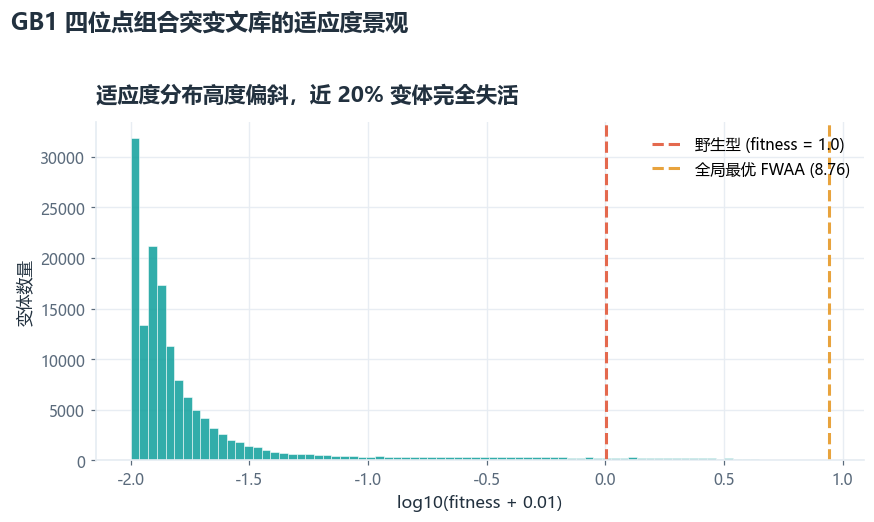

In [4]:
# 图 1：适应度分布
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(df.log_fitness, bins=80, color=PALETTE["teal"], alpha=0.85, edgecolor="white", linewidth=0.4)
ax.axvline(float(to_log_fitness(1.0)), color=PALETTE["coral"], linestyle="--", linewidth=2,
           label="野生型 (fitness = 1.0)")
ax.axvline(df.log_fitness.max(), color=PALETTE["amber"], linestyle="--", linewidth=2,
           label=f"全局最优 {GLOBAL_BEST.variant} ({GLOBAL_BEST.fitness:.2f})")
polish(ax, "适应度分布高度偏斜，近 20% 变体完全失活",
       "log10(fitness + 0.01)", "变体数量")
ax.legend(loc="upper right")

fig.suptitle("GB1 四位点组合突变文库的适应度景观", x=0.012, ha="left",
             fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, "01_fitness_distribution")
plt.show()

[图片已保存] runs/api/img/02_position_aa_landscape.png


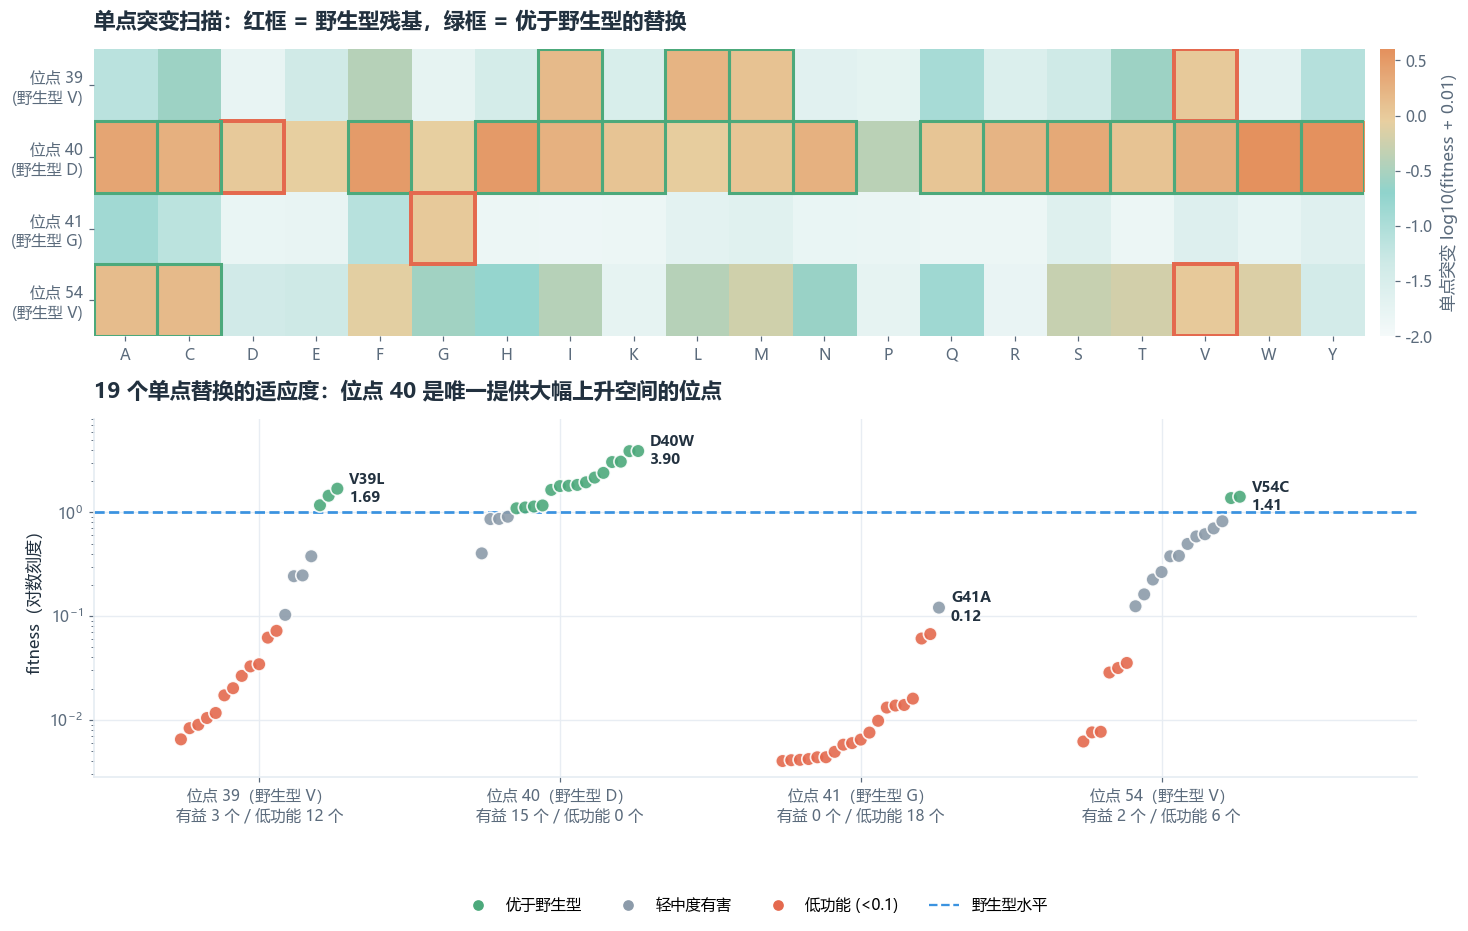

In [5]:
# 图 2：单点突变扫描热图（经典 DMS 视角）+ 各位点单点替换景观
single_fit = {(int(m[1:-1]), m[-1]): f
              for m, f in zip(singles.mutation, singles.fitness)}
mat = np.full((len(MUT_POSITIONS), len(AA_ALPHABET)), np.nan)
for i, p in enumerate(MUT_POSITIONS):
    for j, aa in enumerate(AA_ALPHABET):
        if aa == WT_COMBO[i]:
            mat[i, j] = float(to_log_fitness(1.0))          # 野生型残基
        elif (p, aa) in single_fit:
            mat[i, j] = float(to_log_fitness(single_fit[(p, aa)]))

fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.6),
                         gridspec_kw={"height_ratios": [1.0, 1.25]})

ax = axes[0]
im = ax.imshow(mat, cmap=LIGHT_CMAP, aspect="auto", vmin=-2.0, vmax=0.6)
ax.set_xticks(range(len(AA_ALPHABET))); ax.set_xticklabels(list(AA_ALPHABET))
ax.set_yticks(range(len(MUT_POSITIONS)))
ax.set_yticklabels([f"位点 {p}\n(野生型 {WT_COMBO[i]})" for i, p in enumerate(MUT_POSITIONS)])
for i, p in enumerate(MUT_POSITIONS):
    j = AA_ALPHABET.index(WT_COMBO[i])
    ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                               edgecolor=PALETTE["coral"], linewidth=2.6))
    for jj, aa in enumerate(AA_ALPHABET):
        if not np.isnan(mat[i, jj]) and from_log_fitness(mat[i, jj]) > 1.0 and aa != WT_COMBO[i]:
            ax.add_patch(plt.Rectangle((jj - .5, i - .5), 1, 1, fill=False,
                                       edgecolor=PALETTE["green"], linewidth=2.0))
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.028)
cb.set_label("单点突变 log10(fitness + 0.01)", color=PALETTE["slate"])
cb.outline.set_visible(False)
polish(ax, "单点突变扫描：红框 = 野生型残基，绿框 = 优于野生型的替换",
       None, None, hide=("top", "right", "left", "bottom"))

ax = axes[1]
FLOOR = 0.004
for i, p in enumerate(MUT_POSITIONS):
    sub = singles[singles.position == p].sort_values("fitness").reset_index(drop=True)
    x = np.full(len(sub), i) + np.linspace(-0.26, 0.26, len(sub))
    colors = [PALETTE["green"] if f > 1.0 else (PALETTE["coral"] if f < 0.1 else PALETTE["muted"])
              for f in sub.fitness]
    ax.scatter(x, np.maximum(sub.fitness, FLOOR), c=colors, s=80, alpha=0.9,
               edgecolor="white", linewidth=1.1, zorder=3)
    # 只标注该位点最好的一个替换，且交错放置避免文字重叠
    top = sub.iloc[-1]
    ax.annotate(f"{top.mutation}\n{top.fitness:.2f}",
                (i + 0.30, max(top.fitness, FLOOR)), fontsize=9.5, fontweight="bold",
                color=PALETTE["ink"], va="center", ha="left")
ax.axhline(1.0, color=PALETTE["sky"], linestyle="--", linewidth=1.8)
ax.set_xticks(range(len(MUT_POSITIONS)))
ax.set_xticklabels([f"位点 {p}（野生型 {WT_COMBO[i]}）\n有益 {int((singles[singles.position == p].fitness > 1).sum())} 个 / "
                    f"低功能 {int((singles[singles.position == p].fitness < 0.1).sum())} 个"
                    for i, p in enumerate(MUT_POSITIONS)])
ax.set_xlim(-0.55, len(MUT_POSITIONS) - 0.15)
ax.set_yscale("log"); ax.set_ylim(FLOOR * 0.7, 8.0)
polish(ax, "19 个单点替换的适应度：位点 40 是唯一提供大幅上升空间的位点",
       None, "fitness（对数刻度）")
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=PALETTE["green"], label="优于野生型"),
                   Line2D([], [], marker="o", ls="", color=PALETTE["muted"], label="轻中度有害"),
                   Line2D([], [], marker="o", ls="", color=PALETTE["coral"], label="低功能 (<0.1)"),
                   Line2D([], [], ls="--", color=PALETTE["sky"], label="野生型水平")],
          loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=4)
fig.tight_layout()
save_fig(fig, "02_position_aa_landscape")
plt.show()

In [6]:
# 3. 数据划分：模拟"已完成实验"与"未知候选空间"
#    训练/验证 = 汉明距离 <= 2 的低阶突变（实验室第一轮已经测过的部分）
#    测试/候选 = 汉明距离 >= 3 的高阶组合（尚未测量，Agent 要在其中搜索）
splits = make_splits(df, verbose=True)
save_splits(splits)
train, val, test, known = splits["train"], splits["val"], splits["test"], splits["known"]

print(f"\n[划分] 关键难点：训练集能看到的最高 fitness 只有 {train.fitness.max():.3f}，"
      f"而候选空间里藏着 {test.fitness.max():.3f}。")
print(f"[划分] 模型必须从低阶突变外推到高阶组合，这正是真实定向进化面临的外推问题。")


[划分] 模拟场景：低阶突变 = 已完成实验，高阶组合 = 未知候选空间
  train : n=  1,735  阶数分布={0: 1, 1: 61, 2: 1673}  最高 fitness=5.391
  val   : n=    433  阶数分布={1: 15, 2: 418}  最高 fitness=5.003
  test  : n=147,193  阶数分布={3: 26019, 4: 121174}  最高 fitness=8.762
  训练可见的最优变体 : VWGF (5.391)
  候选空间真实最优   : FWAA (8.762)  <-- Agent 需要找到它
[保存] runs/api/data/processed/gb1_train.csv  (1,735 行)
[保存] runs/api/data/processed/gb1_val.csv  (433 行)
[保存] runs/api/data/processed/gb1_test.csv  (147,193 行)

[划分] 关键难点：训练集能看到的最高 fitness 只有 5.391，而候选空间里藏着 8.762。
[划分] 模型必须从低阶突变外推到高阶组合，这正是真实定向进化面临的外推问题。


In [7]:
# 4. 特征工程
from src.features import describe_encoding, encode, feature_names

describe_encoding(use_physchem=True, use_pairwise=True)
demo = encode(["VDGV", "FWAA"])
print(f"\n[特征] 编码示例：VDGV 与 FWAA -> 矩阵形状 {demo.shape}")
print(f"[特征] 两者特征向量的欧氏距离 = {np.linalg.norm(demo[0] - demo[1]):.3f}")
print(f"[特征] 前 10 个特征名: {feature_names()[:10]}")

[特征] one-hot        : 80 维  (4 位点 × 20 氨基酸)
[特征] 理化描述符     : 28 维  (4 位点 × 7 性质: ['hydropathy', 'volume', 'charge', 'mw', 'helix', 'sheet', 'flexibility'])
[特征] 位点对交互     : 30 维  (6 个位点对 × 5 个描述符)
[特征] 合计           : 138 维

[特征] 编码示例：VDGV 与 FWAA -> 矩阵形状 (2, 138)
[特征] 两者特征向量的欧氏距离 = 9.258
[特征] 前 10 个特征名: ['onehot_P39_A', 'onehot_P39_C', 'onehot_P39_D', 'onehot_P39_E', 'onehot_P39_F', 'onehot_P39_G', 'onehot_P39_H', 'onehot_P39_I', 'onehot_P39_K', 'onehot_P39_L']


In [8]:
# 5. 适应度预测模型：多个 baseline 对比
from src.models import (FitnessModel, compare_models, regression_metrics, print_metrics,
                        MODEL_ZOO, MODEL_DISPLAY, HAS_XGB, topk_metrics)

print(f"[模型] 候选模型: {MODEL_ZOO}")
print("[模型] 训练中（每个模型都在同一套 138 维特征上训练）...\n")
t0 = time.time()
cmp_df = compare_models(train, val, test, verbose=True)
print(f"\n[模型] 全部训练完成，用时 {time.time() - t0:.1f}s")
print("\n[模型] 完整对比表（按验证集 Spearman 排序）")
print(cmp_df.round(4).to_string(index=False))

BEST_KIND = cmp_df.iloc[0]["model"]
print(f"\n[模型] 选定 baseline: {MODEL_DISPLAY[BEST_KIND]}  (验证集 Spearman 最高)")

[模型] 候选模型: ['ridge', 'randomforest', 'extratrees', 'mlp', 'xgboost']
[模型] 训练中（每个模型都在同一套 138 维特征上训练）...



  [Ridge 线性回归      ] 验证 Spearman=0.8505 | 测试 Spearman=0.4720 Pearson=0.5247 MSE=0.6482 recall@100=0.020


  [随机森林            ] 验证 Spearman=0.8911 | 测试 Spearman=0.4562 Pearson=0.6439 MSE=0.1633 recall@100=0.030


  [极端随机树           ] 验证 Spearman=0.8971 | 测试 Spearman=0.4625 Pearson=0.7220 MSE=0.1257 recall@100=0.150


  [多层感知机 MLP       ] 验证 Spearman=0.8579 | 测试 Spearman=0.4586 Pearson=0.6292 MSE=0.2460 recall@100=0.110


  [XGBoost 梯度提升树   ] 验证 Spearman=0.9025 | 测试 Spearman=0.4893 Pearson=0.7047 MSE=0.1552 recall@100=0.190

[模型] 全部训练完成，用时 11.4s

[模型] 完整对比表（按验证集 Spearman 排序）
       model           model_cn  val_spearman  val_pearson  val_mse  val_r2  test_spearman  test_pearson  test_mse  test_mae  test_r2  test_recall@10  test_recall@50  test_recall@100  test_max_true_in_top100  test_ndcg@100
     xgboost XGBoost 梯度提升树        0.9025       0.9598   0.0470  0.9205         0.4893        0.7047    0.1552    0.2871   0.2889             0.0            0.06             0.19                   0.9061         0.9272
  extratrees         极端随机树        0.8971       0.9551   0.0523  0.9116         0.4625        0.7220    0.1257    0.2528   0.4244             0.0            0.06             0.15                   0.7932         0.9061
randomforest           随机森林        0.8911       0.9448   0.0653  0.8896         0.4562        0.6439    0.1633    0.2962   0.2522             0.0            0.02             0.03       

[图片已保存] runs/api/img/03_model_comparison.png


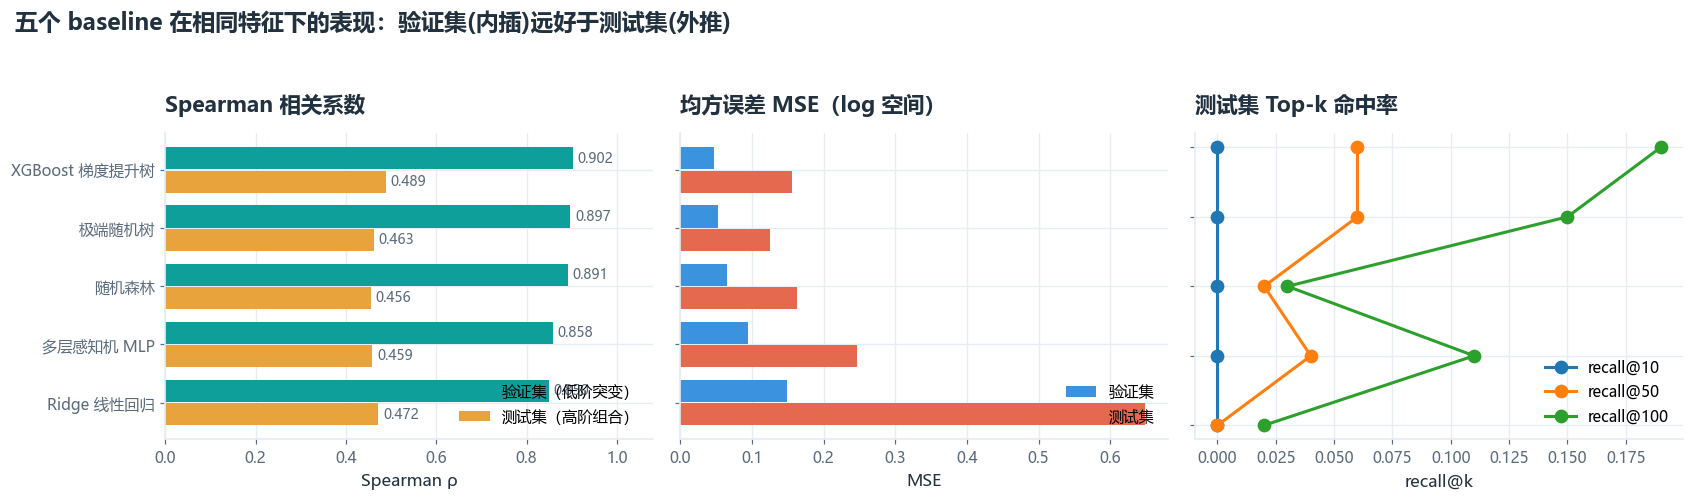

In [9]:
# 图 3：模型对比
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
names = [MODEL_DISPLAY[k] for k in cmp_df.model]
y = np.arange(len(names))

ax = axes[0]
ax.barh(y - 0.2, cmp_df.val_spearman, height=0.38, color=PALETTE["teal"], label="验证集（低阶突变）")
ax.barh(y + 0.2, cmp_df.test_spearman, height=0.38, color=PALETTE["amber"], label="测试集（高阶组合）")
ax.set_yticks(y); ax.set_yticklabels(names); ax.invert_yaxis()
for i, (a, b) in enumerate(zip(cmp_df.val_spearman, cmp_df.test_spearman)):
    ax.text(a + .01, i - .2, f"{a:.3f}", va="center", fontsize=9, color=PALETTE["slate"])
    ax.text(b + .01, i + .2, f"{b:.3f}", va="center", fontsize=9, color=PALETTE["slate"])
ax.set_xlim(0, 1.08)
polish(ax, "Spearman 相关系数", "Spearman ρ", None)
ax.legend(loc="lower right")

ax = axes[1]
ax.barh(y - 0.2, cmp_df.val_mse, height=0.38, color=PALETTE["sky"], label="验证集")
ax.barh(y + 0.2, cmp_df.test_mse, height=0.38, color=PALETTE["coral"], label="测试集")
ax.set_yticks(y); ax.set_yticklabels([]); ax.invert_yaxis()
polish(ax, "均方误差 MSE（log 空间）", "MSE", None)
ax.legend(loc="lower right")

ax = axes[2]
for k in (10, 50, 100):
    ax.plot(cmp_df[f"test_recall@{k}"], y, marker="o", markersize=8,
            label=f"recall@{k}", linewidth=2)
ax.set_yticks(y); ax.set_yticklabels([]); ax.invert_yaxis()
polish(ax, "测试集 Top-k 命中率", "recall@k", None)
ax.legend()

fig.suptitle("五个 baseline 在相同特征下的表现：验证集(内插)远好于测试集(外推)",
             x=0.012, ha="left", fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_fig(fig, "03_model_comparison")
plt.show()

In [10]:
# 6. 最优模型的详细评估
model = FitnessModel(kind=BEST_KIND).fit(train, verbose=True)

print("\n[评估] 三个数据集上的完整指标")
m_train = model.evaluate(train, ks=(10, 50))
m_val = model.evaluate(val, ks=(10, 50))
m_test = model.evaluate(test, ks=(10, 50, 100))
print_metrics("训练集", m_train, ks=(10, 50))
print_metrics("验证集", m_val, ks=(10, 50))
print_metrics("测试集", m_test, ks=(10, 50, 100))

print("\n[评估] 模型能否识别高 fitness 变体？—— 在 147,193 个未知候选里看预测 Top-k 的真实表现")
test_pred = model.predict(test.variant.tolist())
test_eval = test.copy()
test_eval["pred_log"] = test_pred
test_eval["pred_fitness"] = from_log_fitness(test_pred)
for k in (10, 20, 50, 100, 500):
    tk = test_eval.nlargest(k, "pred_log")
    rand_mean = test_eval.fitness.mean()
    print(f"  预测 Top-{k:<4}: 真实 fitness 均值={tk.fitness.mean():6.3f}  最大={tk.fitness.max():6.3f}  "
          f"超野生型比例={(tk.fitness > 1).mean():6.1%}  "
          f"(随机抽样均值仅 {rand_mean:.3f}，富集 {tk.fitness.mean() / rand_mean:.0f} 倍)")

print("\n[评估] 模型预测的 Top-10 候选 vs 真实值")
print(test_eval.nlargest(10, "pred_log")[
    ["variant", "mut_label", "n_mut", "pred_fitness", "fitness"]].round(3).to_string(index=False))

print("\n[评估] 真实 Top-10 变体，模型给了多少分？（暴露模型的系统性盲区）")
真值top = test_eval.nlargest(10, "fitness").copy()
真值top["预测排名"] = 真值top.variant.map(
    {v: i + 1 for i, v in enumerate(test_eval.sort_values("pred_log", ascending=False).variant)})
print(真值top[["variant", "mut_label", "fitness", "pred_fitness", "预测排名"]].round(3).to_string(index=False))

[模型] XGBoost 梯度提升树 训练完成，样本=1,735，特征=138；另训练 60 棵随机化树用于不确定度估计

[评估] 三个数据集上的完整指标


  训练集              n=  1,735 | Spearman=0.9963 Pearson=0.9991 MSE=0.0011 MAE=0.0238 R²=0.9982
                   recall@10=0.900  recall@50=0.920
  验证集              n=    433 | Spearman=0.9025 Pearson=0.9598 MSE=0.0470 MAE=0.1504 R²=0.9205
                   recall@10=0.800  recall@50=0.880
  测试集              n=147,193 | Spearman=0.4893 Pearson=0.7047 MSE=0.1552 MAE=0.2871 R²=0.2889
                   recall@10=0.000  recall@50=0.060  recall@100=0.190

[评估] 模型能否识别高 fitness 变体？—— 在 147,193 个未知候选里看预测 Top-k 的真实表现


  预测 Top-10  : 真实 fitness 均值= 4.429  最大= 5.772  超野生型比例=100.0%  (随机抽样均值仅 0.077，富集 57 倍)
  预测 Top-20  : 真实 fitness 均值= 4.207  最大= 5.772  超野生型比例=100.0%  (随机抽样均值仅 0.077，富集 55 倍)
  预测 Top-50  : 真实 fitness 均值= 4.061  最大= 5.772  超野生型比例=100.0%  (随机抽样均值仅 0.077，富集 53 倍)
  预测 Top-100 : 真实 fitness 均值= 3.826  最大= 8.045  超野生型比例=100.0%  (随机抽样均值仅 0.077，富集 50 倍)
  预测 Top-500 : 真实 fitness 均值= 3.106  最大= 8.762  超野生型比例= 95.6%  (随机抽样均值仅 0.077，富集 40 倍)

[评估] 模型预测的 Top-10 候选 vs 真实值
variant                 mut_label  n_mut  pred_fitness  fitness
   LDCA        V39L + G41C + V54A      3         4.525    4.164
   VHAA        D40H + G41A + V54A      3         4.375    5.111
   FDCA        V39F + G41C + V54A      3         4.108    2.268
   IWGF        V39I + D40W + V54F      3         4.000    5.772
   IDCA        V39I + G41C + V54A      3         3.840    4.130
   LNCA V39L + D40N + G41C + V54A      4         3.825    5.738
   CYGC        V39C + D40Y + V54C      3         3.746    3.568
   IHAA V39I + D40H + G4

[图片已保存] runs/api/img/04_prediction_quality.png


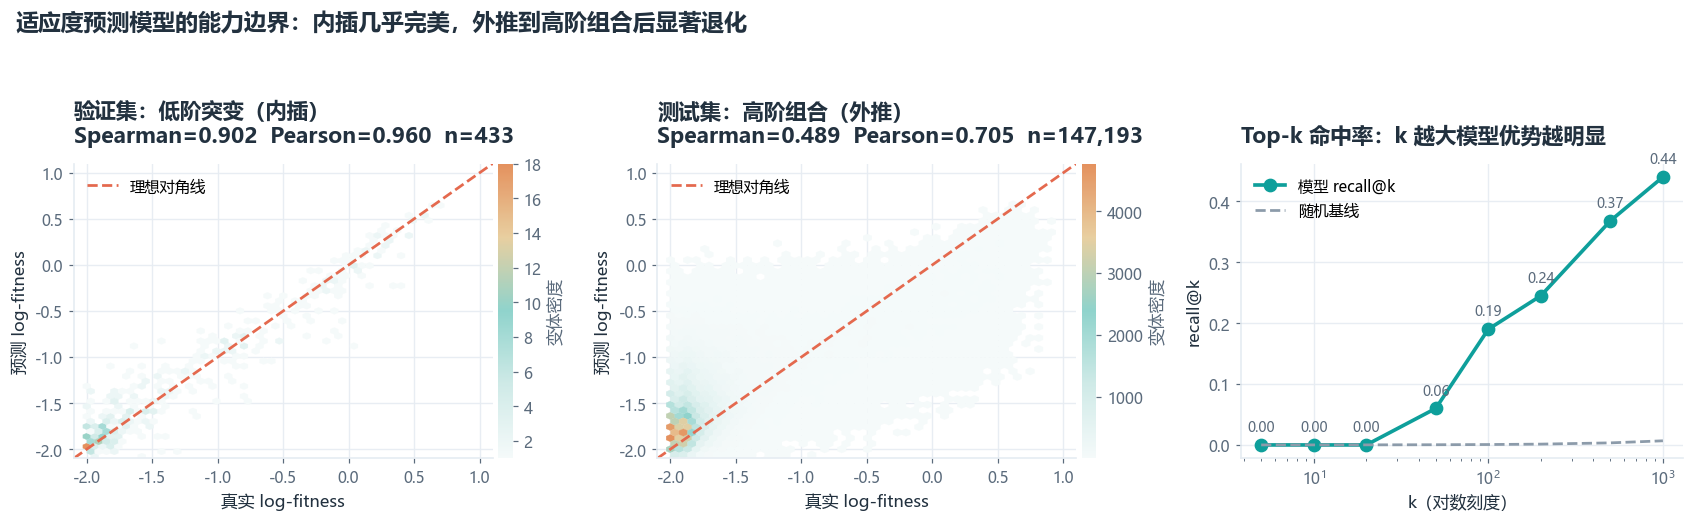

In [11]:
# 图 4：预测 vs 真实
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

for ax, (dset, name) in zip(axes[:2], [(val, "验证集：低阶突变（内插）"),
                                       (test, "测试集：高阶组合（外推）")]):
    p = model.predict(dset.variant.tolist())
    hb = ax.hexbin(dset.log_fitness, p, gridsize=45, cmap=LIGHT_CMAP, mincnt=1, linewidths=0.2)
    lim = [-2.1, 1.1]
    ax.plot(lim, lim, color=PALETTE["coral"], linestyle="--", linewidth=1.8, label="理想对角线")
    ax.set_xlim(lim); ax.set_ylim(lim)
    rho = regression_metrics(dset.log_fitness.values, p)["spearman"]
    r = regression_metrics(dset.log_fitness.values, p)["pearson"]
    polish(ax, f"{name}\nSpearman={rho:.3f}  Pearson={r:.3f}  n={len(dset):,}",
           "真实 log-fitness", "预测 log-fitness")
    ax.legend(loc="upper left")
    cb = fig.colorbar(hb, ax=ax, pad=0.012, fraction=0.04); cb.outline.set_visible(False)
    cb.set_label("变体密度", color=PALETTE["slate"])

ax = axes[2]
ks = [5, 10, 20, 50, 100, 200, 500, 1000]
rec = [topk_metrics(test.log_fitness.values, test_pred, k)[f"recall@{k}"] for k in ks]
ax.plot(ks, rec, marker="o", color=PALETTE["teal"], linewidth=2.4, markersize=8,
        label="模型 recall@k")
ax.plot(ks, [k / len(test) for k in ks], color=PALETTE["muted"], linestyle="--",
        linewidth=1.8, label="随机基线")
ax.set_xscale("log")
for k, v in zip(ks, rec):
    ax.annotate(f"{v:.2f}", (k, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=PALETTE["slate"])
polish(ax, "Top-k 命中率：k 越大模型优势越明显", "k（对数刻度）", "recall@k")
ax.legend()

fig.suptitle("适应度预测模型的能力边界：内插几乎完美，外推到高阶组合后显著退化",
             x=0.012, ha="left", fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, "04_prediction_quality")
plt.show()

[可解释性] Top-18 重要特征
             feature  importance
   pair_41x54_volsum      0.1293
     prop_P41_volume      0.0828
 pair_39x54_hydrosum      0.0512
      prop_P40_sheet      0.0359
        onehot_P40_G      0.0326
        onehot_P41_G      0.0325
         prop_P40_mw      0.0285
         prop_P41_mw      0.0265
        onehot_P41_F      0.0252
  pair_41x54_voldiff      0.0252
 pair_41x54_hydrosum      0.0165
        onehot_P54_N      0.0164
prop_P54_flexibility      0.0157
        onehot_P40_L      0.0151
  pair_39x41_voldiff      0.0145
      prop_P54_sheet      0.0137
     prop_P39_volume      0.0135
        onehot_P39_S      0.0134

[可解释性] 特征重要性汇总到位点
 position  importance  share
       39      0.1742 0.1742
       40      0.2147 0.2147
       41      0.3411 0.3411
       54      0.2700 0.2700


[图片已保存] runs/api/img/05_feature_importance.png


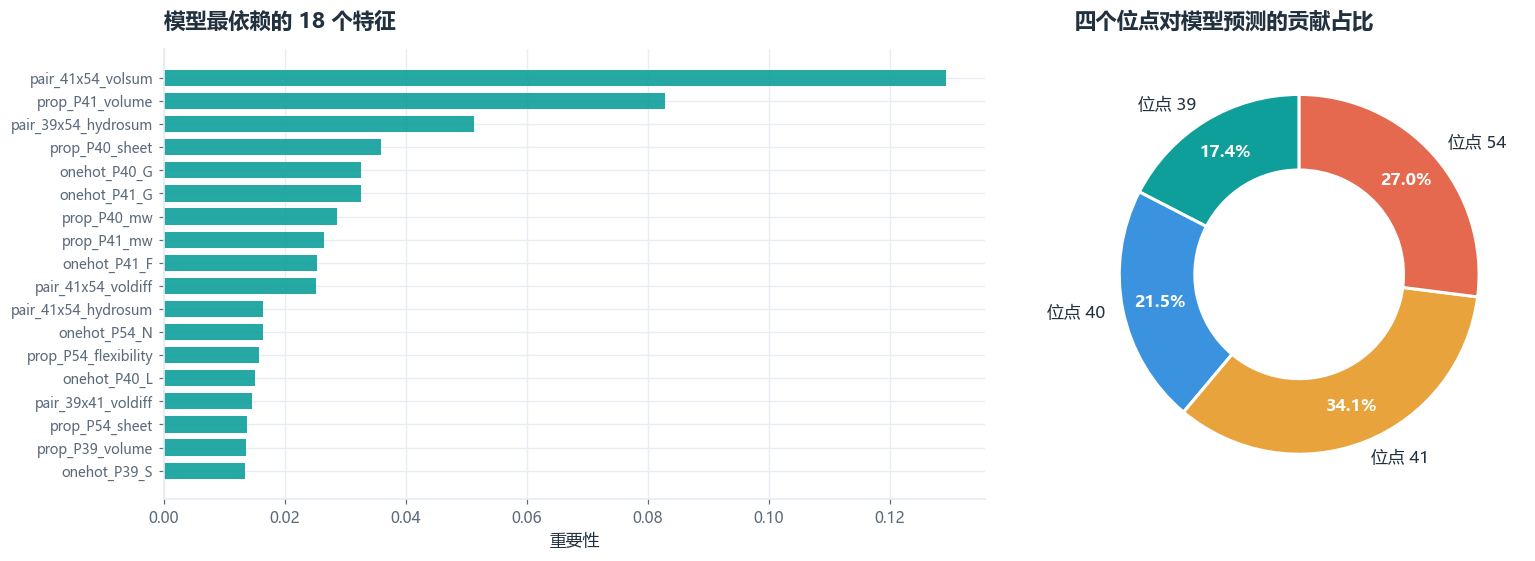

In [12]:
# 图 5：特征重要性与位点重要性
imp = model.feature_importance(top=18)
pos_imp = model.position_importance()
print("[可解释性] Top-18 重要特征")
print(imp.round(4).to_string(index=False))
print("\n[可解释性] 特征重要性汇总到位点")
print(pos_imp.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
yy = np.arange(len(imp))
ax.barh(yy, imp.importance, color=PALETTE["teal"], alpha=0.9, height=0.7)
ax.set_yticks(yy); ax.set_yticklabels(imp.feature, fontsize=9); ax.invert_yaxis()
polish(ax, "模型最依赖的 18 个特征", "重要性", None)

ax = axes[1]
cols = [SERIES_COLORS[i] for i in range(len(pos_imp))]
wedges, _, autotexts = ax.pie(pos_imp.share, labels=[f"位点 {p}" for p in pos_imp.position],
                              colors=cols, autopct="%1.1f%%", pctdistance=0.79, startangle=90,
                              wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
                              textprops=dict(color=PALETTE["ink"], fontsize=11))
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
ax.set_title("四个位点对模型预测的贡献占比", loc="left", color=PALETTE["ink"])
ax.grid(False)

fig.tight_layout()
save_fig(fig, "05_feature_importance")
plt.show()

In [13]:
# 7. 知识增强 (1)：氨基酸理化性质知识库
from src.knowledge import (aa_table, AA_PROPERTIES, BLOSUM62, blosum_score,
                           substitution_class, property_delta, describe_substitution,
                           STRUCTURAL_CONTEXT, POLARITY_GROUPS, DesignRuleBook, KnowledgeGraph)

aa_df = aa_table()
print("[知识库] 20 种氨基酸的理化性质表")
print(aa_df[["name", "tla", "hydropathy", "volume", "charge", "mw",
             "polarity", "aromatic", "helix", "sheet", "flexibility"]].to_string())

print("\n[知识库] GB1 四个可突变位点的结构环境注释")
for p, c in STRUCTURAL_CONTEXT.items():
    print(f"  位点 {p} (野生型 {c['wt']}): {c['element']} | {c['burial']}")
    print(f"           {c['note']}")

print("\n[知识库] BLOSUM62 替换分类示例（本项目关心的几个替换）")
for a, pos, b in [("D", 40, "W"), ("D", 40, "Y"), ("V", 39, "F"), ("V", 39, "I"),
                  ("G", 41, "A"), ("G", 41, "P"), ("V", 54, "A"), ("V", 54, "P")]:
    d = property_delta(a, b)
    print(f"  {a}{pos}{b}: {substitution_class(a, b):<8} BLOSUM62={blosum_score(a, b):+2d}  "
          f"Δ体积={d['volume']:+7.1f}Å³  Δ疏水={d['hydropathy']:+5.1f}  Δ电荷={d['charge']:+4.1f}")

print("\n[知识库] 自然语言解释示例（Agent 会把这类描述写进推荐理由）")
for a, pos, b in [("D", 40, "W"), ("G", 41, "A")]:
    print(f"  {describe_substitution(a, pos, b)}")

[知识库] 20 种氨基酸的理化性质表
             name  tla  hydropathy  volume  charge      mw  polarity  aromatic  helix  sheet  flexibility
aa                                                                                                       
A         Alanine  Ala         1.8    88.6     0.0   89.09  nonpolar     False   1.42   0.83         0.36
C        Cysteine  Cys         2.5   108.5     0.0  121.16     polar     False   0.70   1.19         0.35
D       Aspartate  Asp        -3.5   111.1    -1.0  133.10  negative     False   1.01   0.54         0.51
E       Glutamate  Glu        -3.5   138.4    -1.0  147.13  negative     False   1.51   0.37         0.50
F   Phenylalanine  Phe         2.8   189.9     0.0  165.19  nonpolar      True   1.13   1.38         0.31
G         Glycine  Gly        -0.4    60.1     0.0   75.07  nonpolar     False   0.57   0.75         0.54
H       Histidine  His        -3.2   153.2     0.5  155.16  positive      True   1.00   0.87         0.32
I      Isoleucine  Ile    

[图片已保存] runs/api/img/06_amino_acid_knowledge.png


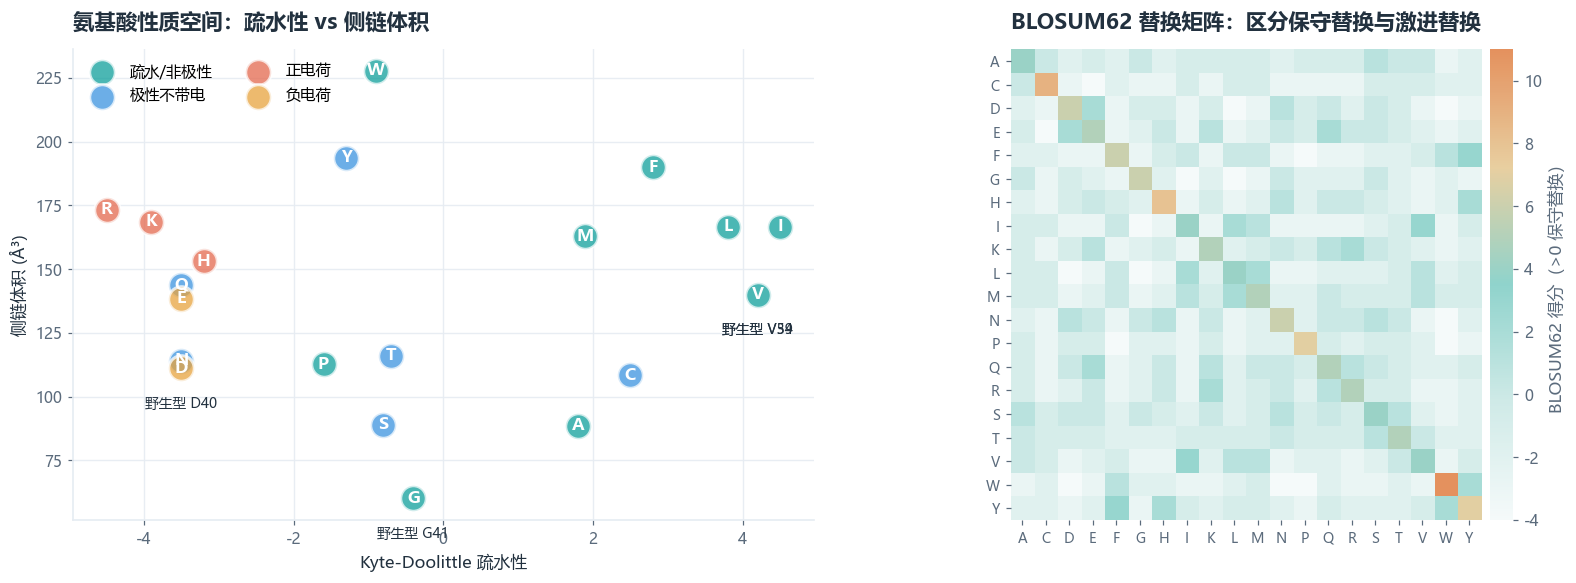

In [14]:
# 图 6：氨基酸性质空间
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

ax = axes[0]
pol_color = {"nonpolar": PALETTE["teal"], "polar": PALETTE["sky"],
             "positive": PALETTE["coral"], "negative": PALETTE["amber"]}
for pol, c in pol_color.items():
    sub = aa_df[aa_df.polarity == pol]
    ax.scatter(sub.hydropathy, sub.volume, s=280, color=c, alpha=0.75,
               edgecolor="white", linewidth=2, label=POLARITY_GROUPS[pol], zorder=3)
    for aa, r in sub.iterrows():
        ax.annotate(aa, (r.hydropathy, r.volume), ha="center", va="center",
                    fontsize=11, fontweight="bold", color="white", zorder=4)
for i, p in enumerate(MUT_POSITIONS):
    aa = WT_COMBO[i]
    r = aa_df.loc[aa]
    ax.annotate(f"野生型 {aa}{p}", (r.hydropathy, r.volume),
                textcoords="offset points", xytext=(0, -26), ha="center",
                fontsize=9, color=PALETTE["ink"])
polish(ax, "氨基酸性质空间：疏水性 vs 侧链体积", "Kyte-Doolittle 疏水性", "侧链体积 (Å³)")
ax.legend(loc="upper left", ncol=2)

ax = axes[1]
b62 = np.array([[blosum_score(a, b) for b in AA_ALPHABET] for a in AA_ALPHABET])
im = ax.imshow(b62, cmap=LIGHT_CMAP)
ax.set_xticks(range(20)); ax.set_xticklabels(list(AA_ALPHABET), fontsize=9)
ax.set_yticks(range(20)); ax.set_yticklabels(list(AA_ALPHABET), fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.045); cb.outline.set_visible(False)
cb.set_label("BLOSUM62 得分（>0 保守替换）", color=PALETTE["slate"])
polish(ax, "BLOSUM62 替换矩阵：区分保守替换与激进替换", None, None,
       hide=("top", "right", "left", "bottom"))

fig.tight_layout()
save_fig(fig, "06_amino_acid_knowledge")
plt.show()

In [15]:
# 8. 知识增强 (2)：突变设计规则库
from src.agent import epistasis_table, pair_preference, position_sensitivity

epi_known = epistasis_table(known)
rulebook = DesignRuleBook().learn_from_history(
    known, epistasis_records=pair_preference(epi_known), verbose=True)

print("\n[规则库] 10 条设计规则逐条演示")
demo_variants = [("VWGF", "训练集中已知最优"), ("FWAA", "真实全局最优"),
                 ("VPGP", "在 β 股引入脯氨酸"), ("CCCC", "四个位点全换成半胱氨酸"),
                 ("VDAV", "只引入 G41A（无伙伴突变）")]
for v, note in demo_variants:
    res = rulebook.evaluate(v, parent="VWGF")
    真实 = df.loc[df.variant == v, "fitness"]
    真实 = f"{float(真实.iloc[0]):.3f}" if len(真实) else "文库中缺测"
    print(f"\n  ── {v} ({mutation_label(v)}) —— {note}；真实 fitness = {真实}")
    print(f"     可行性={res['feasible']}  规则通过 {res['n_pass']}/{res['n_total']}  "
          f"软性惩罚={res['penalty']}")
    for c in res["checks"]:
        flag = "✓" if c["passed"] else ("✗硬性" if c["severity"] == "hard" else "!软性")
        print(f"       [{c['rule_id']}] {flag} {c['name']}: {c['message']}")

print("\n[规则库] 关键设计：规则是先验，实验证据可以推翻先验")
print("  R7 的先验是'不要动位点 41'，但 GB1 的全局最优恰好含 G41A。")
print("  因此当变体中同时含有被实测验证能补偿它的伙伴突变时，R7 按'有条件放行'处理。")
print(f"  当前具备上位效应补偿证据的突变共 {len(rulebook.rescue_partners)} 个：")
for m in sorted(rulebook.rescue_partners)[:8]:
    print(f"    {m:<6} 可被 {sorted(rulebook.rescue_partners[m])[:5]} 补偿")

[规则库] 从历史数据学到 20 个有益单点突变，36 个低功能单点突变，15 个突变具备上位效应补偿证据
        有益单点 Top8: ['D40W', 'D40Y', 'D40H', 'D40F', 'D40A', 'D40S', 'D40V', 'D40C']
        例: V39W 可被 ['G41F', 'G41L'] 补偿

[规则库] 10 条设计规则逐条演示

  ── VWGF (D40W + V54F) —— 训练集中已知最优；真实 fitness = 5.391
     可行性=True  规则通过 10/10  软性惩罚=0.0
       [R1] ✓ 序列合法性: 全部为 20 种标准氨基酸，无终止密码子/非标准残基。
       [R2] ✓ 突变数量上限: 共 2 个突变，未超过文库允许的 4 个位点。
       [R3] ✓ 单轮突变跨度: 相对当前最优变体 VWGF 只改动 0 个位点，符合小步迭代策略。
       [R4] ✓ 保守/激进替换平衡: 激进替换 1 个(D40W)，在可接受范围内。
       [R5] ✓ β 折叠股禁脯氨酸: 未在 β 折叠股内引入脯氨酸。
       [R6] ✓ 自由半胱氨酸风险: 未引入额外的自由半胱氨酸。
       [R7] ✓ 主链受限位点: 未改动主链构象受限的高风险位点。
       [R8] ✓ 净电荷平衡: 净电荷变化 +1.0，在可接受范围内。
       [R9] ✓ 复用历史有益突变: 包含历史验证的有益单点 D40W，组合效应仍需实验确认。
       [R10] ✓ 规避已知低功能突变: 未包含缺少组合补偿证据的历史低功能单点突变。

  ── FWAA (V39F + D40W + G41A + V54A) —— 真实全局最优；真实 fitness = 8.762
     可行性=True  规则通过 9/10  软性惩罚=0.15
       [R1] ✓ 序列合法性: 全部为 20 种标准氨基酸，无终止密码子/非标准残基。
       [R2] ✓ 突变数量上限: 共 4 个突变，未超过文库允许的 4 个位点。
       [R3] !软性 单轮突变跨度: 相对 VWGF 一次改动 3 个位点，跨度过大，上位效

In [16]:
# 9. 知识增强 (3)：上位效应挖掘 —— 本项目最关键的科学信号
print(f"[上位效应] 从 {len(known[known.n_mut == 2])} 个双突变体中计算 "
      f"epistasis = 观测 log-fitness − 加性期望")
print(f"[上位效应] 共提取 {len(epi_known)} 对可计算的突变组合，"
      f"其中符号上位（突变效应随背景翻转）{int(epi_known.sign_epistasis.sum())} 对")

print("\n[上位效应] 按设计价值评分排序的 Top-12 突变对（Agent 会以它们为设计骨架）")
pref = pd.DataFrame(pair_preference(epi_known))
print(pref.head(12).round(3).to_string(index=False))

print("\n[上位效应] 重点案例：G41A + V54A")
row = epi_known[(epi_known.mut_a == "G41A") & (epi_known.mut_b == "V54A")]
if len(row):
    r = row.iloc[0]
    print(f"  G41A 单点 fitness = {r.single_a_fitness:.4f}（几乎失活）")
    print(f"  V54A 单点 fitness = {r.single_b_fitness:.4f}（略优于野生型）")
    print(f"  加性模型期望      = {from_log_fitness(r.exp_log_fitness):.4f}")
    print(f"  实际组合 fitness  = {r.obs_fitness:.4f}  ← 比期望高 {r.epistasis:+.3f} (log 空间)")
    print("  结论：该双突变中 G41A 的作用方向随 V54A 背景翻转，组合效应需要实测验证。")

print("\n[上位效应] 位点画像（区分'波动幅度'和'上升空间'两个容易混淆的概念）")
print(position_sensitivity(known).round(3).to_string(index=False))

[上位效应] 从 2091 个双突变体中计算 epistasis = 观测 log-fitness − 加性期望
[上位效应] 共提取 2091 对可计算的突变组合，其中符号上位（突变效应随背景翻转）637 对

[上位效应] 按设计价值评分排序的 Top-12 突变对（Agent 会以它们为设计骨架）
mut_a mut_b  obs_fitness  epistasis  design_score  sign_epistasis  single_a_fitness  single_b_fitness
 V39W  G41L        2.087      3.720         2.182            True             0.010             0.010
 V39W  G41F        2.553      3.217         2.017            True             0.010             0.067
 G41L  V54G        3.145      2.767         1.882            True             0.010             0.266
 G41F  V54G        2.651      2.102         1.476            True             0.067             0.266
 G41C  V54A        3.687      1.582         1.359            True             0.061             1.373
 G41A  V54A        4.158      1.368         1.304            True             0.121             1.373
 G41A  V54G        2.368      1.824         1.288            True             0.121             0.266
 G41C  V54G        1.919      1

[图片已保存] runs/api/img/07_epistasis_analysis.png


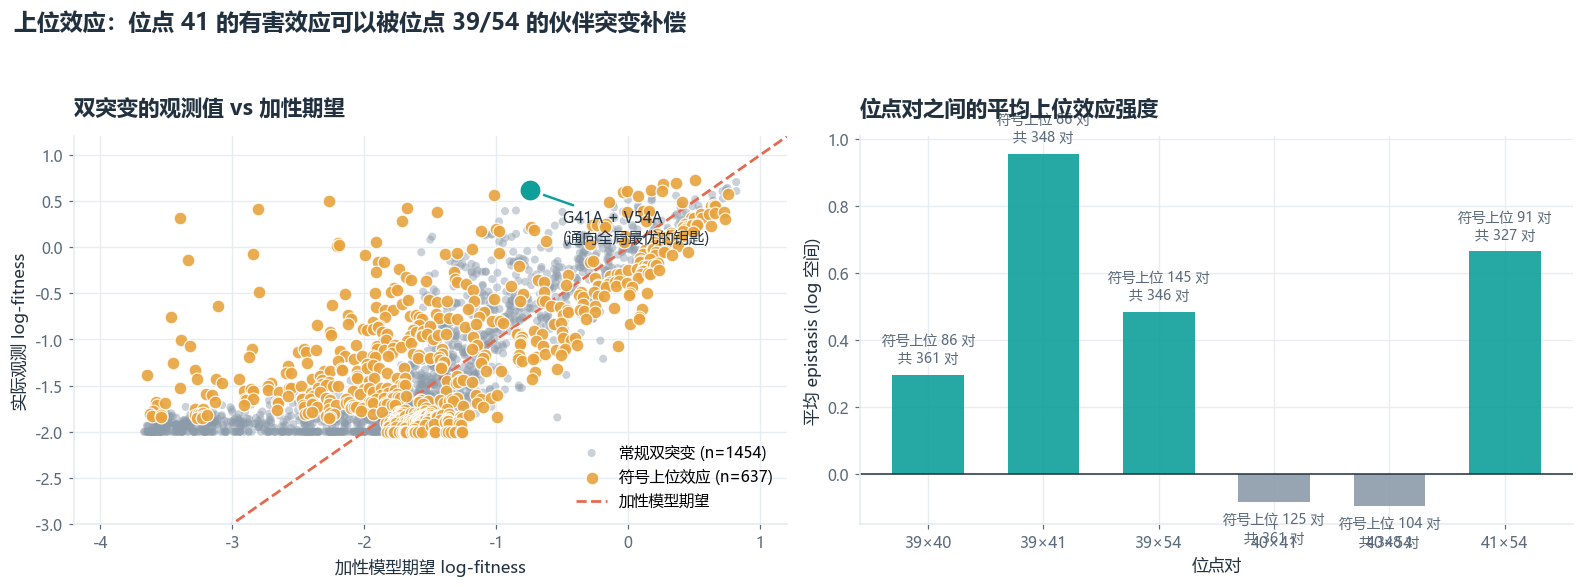

In [17]:
# 图 7：上位效应分析
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

ax = axes[0]
neg = epi_known[~epi_known.sign_epistasis]
sig = epi_known[epi_known.sign_epistasis]
ax.scatter(neg.exp_log_fitness, neg.obs_log_fitness, s=28, color=PALETTE["muted"],
           alpha=0.45, edgecolor="none", label=f"常规双突变 (n={len(neg)})")
ax.scatter(sig.exp_log_fitness, sig.obs_log_fitness, s=70, color=PALETTE["amber"],
           alpha=0.9, edgecolor="white", linewidth=0.8, zorder=3,
           label=f"符号上位效应 (n={len(sig)})")
lim = [-4.2, 1.2]
ax.plot(lim, lim, color=PALETTE["coral"], linestyle="--", linewidth=1.8, label="加性模型期望")
key = epi_known[(epi_known.mut_a == "G41A") & (epi_known.mut_b == "V54A")]
if len(key):
    k = key.iloc[0]
    ax.scatter([k.exp_log_fitness], [k.obs_log_fitness], s=230, color=PALETTE["teal"],
               edgecolor="white", linewidth=2.2, zorder=5)
    ax.annotate("G41A + V54A\n(通向全局最优的钥匙)",
                (k.exp_log_fitness, k.obs_log_fitness), textcoords="offset points",
                xytext=(22, -34), fontsize=10, color=PALETTE["ink"],
                arrowprops=dict(arrowstyle="->", color=PALETTE["teal"], linewidth=1.6))
ax.set_xlim(lim); ax.set_ylim(-3.0, 1.2)
polish(ax, "双突变的观测值 vs 加性期望", "加性模型期望 log-fitness", "实际观测 log-fitness")
ax.legend(loc="lower right")

ax = axes[1]
pos_pairs = epi_known.groupby(["pos_a", "pos_b"]).agg(
    mean_epi=("epistasis", "mean"), n=("epistasis", "size"),
    n_sign=("sign_epistasis", "sum")).reset_index()
labels = [f"{int(a)}×{int(b)}" for a, b in zip(pos_pairs.pos_a, pos_pairs.pos_b)]
xx = np.arange(len(labels))
bars = ax.bar(xx, pos_pairs.mean_epi, width=0.62,
              color=[PALETTE["teal"] if v > 0 else PALETTE["muted"] for v in pos_pairs.mean_epi],
              alpha=0.9)
for i, r in pos_pairs.iterrows():
    ax.annotate(f"符号上位 {int(r.n_sign)} 对\n共 {int(r.n)} 对",
                (i, r.mean_epi), textcoords="offset points",
                xytext=(0, 8 if r.mean_epi > 0 else -26), ha="center",
                fontsize=9, color=PALETTE["slate"])
ax.set_xticks(xx); ax.set_xticklabels(labels)
ax.axhline(0, color=PALETTE["ink"], linewidth=1.0)
polish(ax, "位点对之间的平均上位效应强度", "位点对", "平均 epistasis (log 空间)")

fig.suptitle("上位效应：位点 41 的有害效应可以被位点 39/54 的伙伴突变补偿",
             x=0.012, ha="left", fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_fig(fig, "07_epistasis_analysis")
plt.show()

In [18]:
# 10. 知识增强 (4)：知识图谱
kg = KnowledgeGraph.build(known, verbose=True)
kg.save()

print("\n[知识图谱] 三元组样例")
for t in kg.triples[:6]:
    print("   ", t)
print("    ...")
for t in kg.query(rel="improves")[:5]:
    print("   ", t)

print(f"\n[知识图谱] 查询：提升适应度的突变共 {len(kg.beneficial_mutations())} 个")
print(f"           {kg.beneficial_mutations()[:12]}")
print(f"[知识图谱] 查询：导致功能丧失的突变共 {len(kg.lethal_mutations())} 个")
print(f"           {kg.lethal_mutations()[:12]}")
print(f"[知识图谱] 查询：位点 41 上已测量的突变 -> {kg.mutations_at(41)[:10]}")
print(f"[知识图谱] 查询：色氨酸 W 的性质 -> {kg.properties_of('W')}")

print("\n[知识图谱] 用于生成推荐理由的路径解释（Agent 的 Scientific Critic 直接调用）")
for m in ["D40W", "G41A", "V54A", "V39F"]:
    print(f"  {kg.explain_mutation(m)}")

[知识图谱] 三元组 375 条，节点 134 个
[知识图谱] 关系类型: ['abolishes', 'conservative_to', 'contains', 'has_phenotype', 'has_property', 'impairs', 'improves', 'introduces', 'located_in', 'occurs_at', 'wild_type_is']
[保存] 知识图谱 -> runs/api/results/knowledge_graph.json

[知识图谱] 三元组样例
    ('A', 'has_property', '疏水/非极性')
    ('A', 'has_property', '疏水')
    ('A', 'has_property', '小体积(<110Å³)')
    ('C', 'has_property', '极性不带电')
    ('C', 'has_property', '疏水')
    ('C', 'has_property', '小体积(<110Å³)')
    ...
    ('V39I', 'improves', 'Fitness')
    ('V39L', 'improves', 'Fitness')
    ('V39M', 'improves', 'Fitness')
    ('D40A', 'improves', 'Fitness')
    ('D40C', 'improves', 'Fitness')

[知识图谱] 查询：提升适应度的突变共 20 个
           ['V39I', 'V39L', 'V39M', 'D40A', 'D40C', 'V54A', 'V54C', 'D40F', 'D40H', 'D40I', 'D40K', 'D40M']
[知识图谱] 查询：导致功能丧失的突变共 36 个
           ['V39A', 'V39D', 'V39E', 'V39G', 'V39H', 'V39K', 'V39N', 'V39P', 'V39R', 'V39S', 'G41C', 'G41D']
[知识图谱] 查询：位点 41 上已测量的突变 -> ['G41A', 'G41C', 'G41D', 'G41E', 'G41F

[图片已保存] runs/api/img/08_knowledge_graph.png


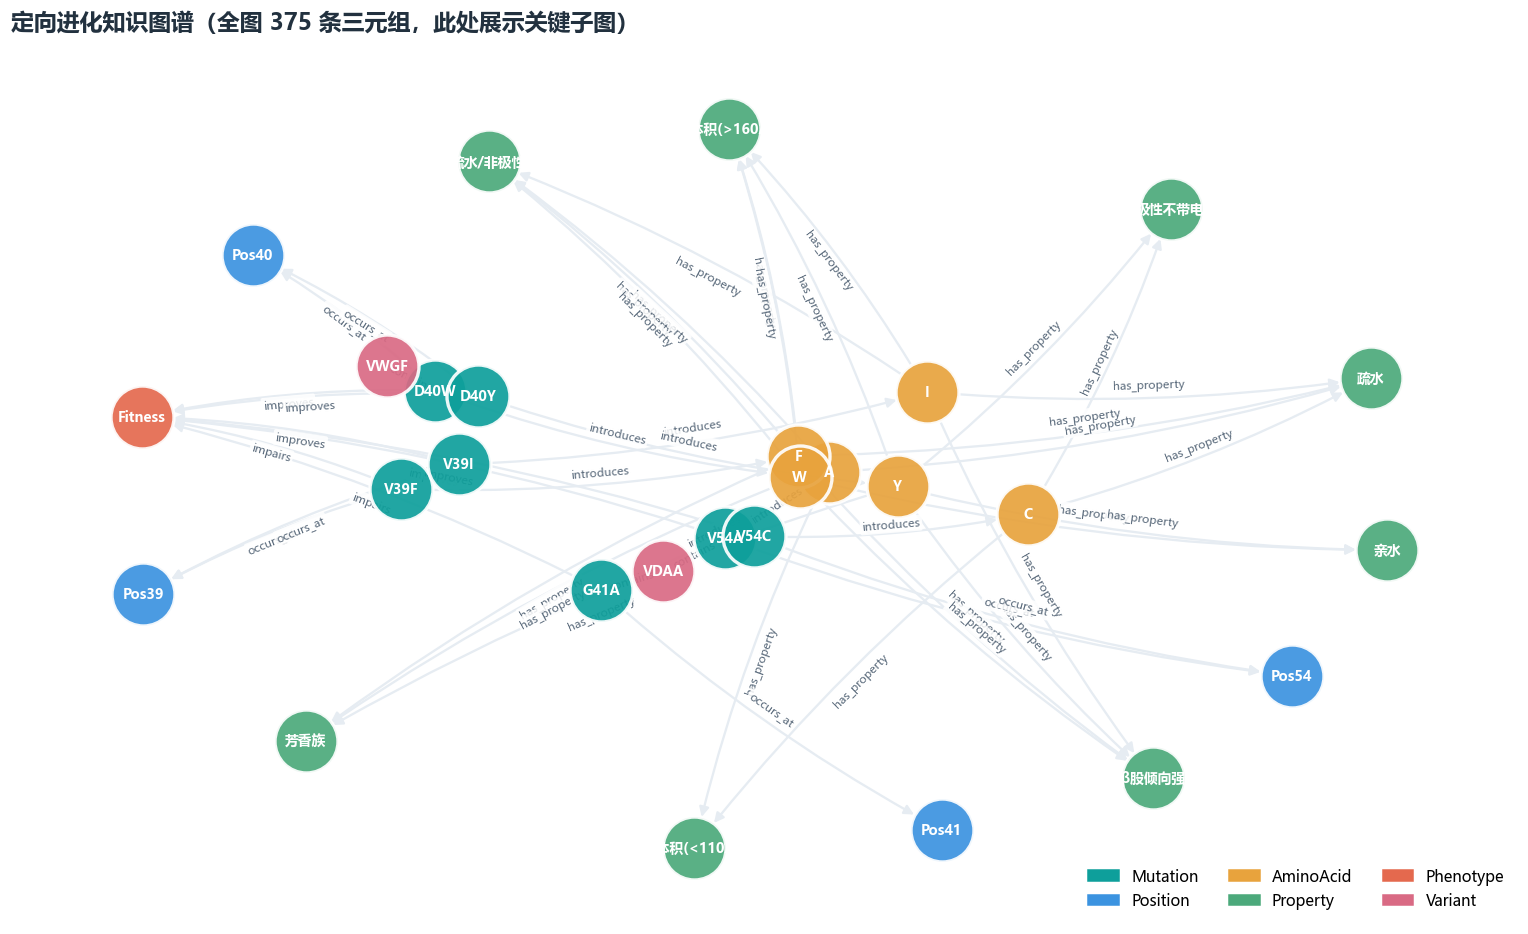

In [19]:
# 图 8：知识图谱可视化
import networkx as nx

G = nx.DiGraph()
focus_muts = ["D40W", "D40Y", "V39F", "V39I", "G41A", "V54A", "V54C"]
focus_vars = ["FWAA", "VWGF", "VDAA"]
keep = []
for h, r, t in kg.triples:
    if h in focus_muts and r in ("occurs_at", "introduces"):
        keep.append((h, r, t))
    elif h in focus_muts and r in ("improves", "impairs", "abolishes"):
        keep.append((h, r, t))
    elif h in focus_vars and r == "contains" and t in focus_muts:
        keep.append((h, r, t))
    elif h in [m[-1] for m in focus_muts] and r == "has_property":
        keep.append((h, r, t))
for h, r, t in keep:
    G.add_edge(h, t, rel=r)

TYPE_COLOR = {"Mutation": PALETTE["teal"], "Position": PALETTE["sky"],
              "AminoAcid": PALETTE["amber"], "Property": PALETTE["green"],
              "Phenotype": PALETTE["coral"], "Variant": PALETTE["rose"],
              "StructuralElement": PALETTE["muted"], "Entity": PALETTE["muted"]}
node_types = {n: kg.node_types.get(n, "Entity") for n in G.nodes}

pos = nx.spring_layout(G, seed=7, k=1.05, iterations=320)
fig, ax = plt.subplots(figsize=(14, 8.6))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=PALETTE["grid"], width=1.5,
                       arrows=True, arrowsize=13, arrowstyle="-|>",
                       connectionstyle="arc3,rad=0.06", node_size=1700)
for t, c in TYPE_COLOR.items():
    ns = [n for n in G.nodes if node_types[n] == t]
    if ns:
        nx.draw_networkx_nodes(G, pos, nodelist=ns, ax=ax, node_color=c, node_size=1700,
                               alpha=0.92, edgecolors="white", linewidths=2.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white",
                        font_family="Microsoft YaHei", font_weight="bold")
elabels = {(u, v): d["rel"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=elabels, ax=ax, font_size=7.5,
                             font_family="Microsoft YaHei", font_color=PALETTE["slate"],
                             bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85))
ax.set_axis_off()
ax.set_title(f"定向进化知识图谱（全图 {len(kg.triples):,} 条三元组，此处展示关键子图）",
             loc="left", fontsize=15, fontweight="bold", color=PALETTE["ink"], pad=16)
ax.legend(handles=[mpatches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()
                   if any(node_types[n] == t for n in G.nodes)],
          loc="lower right", ncol=3)
fig.tight_layout()
save_fig(fig, "08_knowledge_graph")
plt.show()

In [20]:
# 11. 科学智能体：单轮分析、假设、设计、评估与审查
from src.llm import LLMClient
from src.agent import AgentConfig, DirectedEvolutionAgent
from src.baselines import RandomStrategy, ModelGreedyStrategy

llm = LLMClient(backend=os.environ.get("LLM_BACKEND", "auto"), allow_fallback=False)
llm.banner()
AGENT_NAME = "LLM-Agent" if llm.backend == "api" else "Rule-Agent"
KB_NAME = AGENT_NAME + "+KB"
llm_repl = LLMClient(backend="offline")
print(f"[实验设置] 主实验: {llm.backend}；规则引擎重复实验: offline。两类结果分开统计。")
allowed = set(df.variant)
oracle_full = VirtualLabOracle.from_dataframe(df, already_measured=known.variant)
agent_kb = DirectedEvolutionAgent(
    llm, AgentConfig(name=KB_NAME, use_knowledge=True), DesignRuleBook(), kg)
demo_model = FitnessModel(kind=BEST_KIND).fit(known)
demo_prop = agent_kb.propose(known, demo_model, allowed, round_id=1, verbose=True)


[LLM] 后端 = api  |  OpenAI 兼容接口 · deepseek-flash @ https://api.deepseek.com/v1
[实验设置] 主实验: api；规则引擎重复实验: offline。两类结果分开统计。



────────────────────────────────────────────────────────────────────────────────────────────────
【LLM-Agent+KB】第 1 轮  |  已测 2168 个变体  |  当前最优 VWGF(D40W + V54F) = 5.391
────────────────────────────────────────────────────────────────────────────────────────────────


  [规则库] 已验证有益单点 20 个，低功能单点 36 个，具备上位效应补偿证据的突变 15 个
  [1/5 Data Analyst] 2168个变体，最优VWGF(D40W+V54F)适应度5.391。位点40增益最强，15个有益单点，D40W/Y/H/F突出。V39L/I、V54C/A为其他有益单点。位点41单点上升空间为负且多低功能，但G41A/C与V54组合有正上位。39/54低功能替换多。超野生型仅10.1%。
        · 位点40是主要增益来源：15个有益单点，无低功能，最优单点D40W=3.90。
        · 位点41单点上升空间-0.888，0个有益单点、18个低功能；G41A+V54A达4.158。
        · 位点39和54波动大，有益残基少：V39L/I、V54C/A有益，但分别有12/6个低功能单点。
        · Top变体多为双突变，D40W/Y与V39L/I或V54F/M/C/A组合，最高VWGF=5.391。
        · 双突变中637对呈符号上位；V39W+G41L、G41L+V54G等正上位明显。
        · 适应度中位数0.0196，仅10.1%变体超过野生型，多数低于野生型。


  [2/5 Hypothesis Generator] 生成 5 条假设：
        [H1|exploit|conf=0.6] 在VWGF骨架上引入V39L/I，填充界面疏水堆积，提升稳定性与亲和力。
              理由: 位点39部分埋藏，L/I疏水且体积适中，利于界面堆积；V39L单点1.69且LYGV=5.075，BLOSUM62 V→L保守，与D40W/V54F可能协同。
        [H2|recombine|conf=0.55] 重组LYGV与VWGF：在V54F背景比较D40Y/W并加V39L。
              理由: 位点40表面暴露热点，W/Y芳香单点3.90/3.89；Y体积194<W228，或缓解39L堆积；LYGV=5.075，与V54F重组有望超5.391，BLOSUM62 W→Y保守。
        [H3|epistasis|conf=0.42] 在VWGF骨架上叠加V39W+G41L，利用强正上位提升界面堆积。
              理由: 已测V39W+G41L上位+3.720、V39W+G41F上位+3.217；39W芳香堆积，41L/F缓解甘氨酸主链张力。V→W(-3)、G→L(-4)激进，但有上位补偿，须限2个激进替换。
        [H4|epistasis|conf=0.35] 在VWGF上试探G41A/C，检验其与V54F的潜在正上位。
              理由: 位点41主链受限，单点多低功能；但G41A+V54A=4.158、G41C+V54A=3.687正上位显著。A体积小可减压，C需谨慎；V54F疏水核或可容纳，优先A。
        [H5|explore|conf=0.4] 在D40W背景下比较V54C/M/L并加V39L，优化β核疏水堆积。
              理由: 位点54埋藏β4，忌Pro/强极性；V54C单点有益、β倾向1.19，VWGC=4.239。C/M/L体积108-167小于F190，或缓解核内拥挤；加V39L增强界面，Cys需谨慎。


  [3/5 Mutation Designer] 生成候选 469 条，来源分布: {'random_exploration': 150, 'epistasis_extension': 149, 'residue_enumeration': 105, 'recombine': 47, 'llm_seed': 18}
  [4/5 Fitness Evaluator] 预测适应度范围 0.003 ~ 5.437，预测优于当前最优的候选 1 条


  [5/5 Scientific Critic] 规则筛选后 467 条，最终选出 12 条送入虚拟实验
        批次评价: 总体：VHAA预测最高但含G41A降活，需优先验证；多数候选含已知降活/功能丧失单点或跨度大，建议聚焦无有害单点且预测较高者；WDLT/WDFA含双功能丧失突变，明确拒绝。；两候选均属高不确定上位扩展，预测远低于VWGF且缺关键有益突变；建议仅作探索，优先验证补偿与折叠功能。


In [21]:
# 12. 展示 Agent 五个模块的完整 prompt 与输出（写报告时直接引用）
for step in ["data_analysis", "hypothesis", "mutation_design", "critic"]:
    turn = llm.last(step)
    if turn is not None:
        llm.print_turn(turn, show_prompt=True, max_prompt_chars=2600)

# 统计真实大模型的调用情况：调用次数、回退次数、token 消耗（含推理型模型的思维链）
llm.print_usage()
print()
print("[后端来源] 本次演示每个模块的结果实际来自：")
for t in llm.transcript:
    print(f"  {t.role:34s} step={t.step:16s} 来源={t.backend:24s} "
          f"耗时={t.latency_s:6.1f}s  思维链={len(t.reasoning):6d} 字符")


[Agent 模块] Data Analyst（实验数据分析师）   [步骤] data_analysis   [轮次] R1   [后端] api   [耗时] 27.442s
--- SYSTEM PROMPT ----------------------------------------------------------------------------------
你是一名蛋白质工程实验室的数据分析师。你的任务是阅读一轮定向进化的实验结果，客观地总结数据里呈现的规律：哪些位点对适应度影响最大、哪些残基替换有益、哪些组合出现了超出加性预期的效应。只陈述数据支持的结论，不要臆测。必须只输出一个 JSON 对象，字段为 {"summary": str, "key_positions": [int], "beneficial_residues": [{"position": int, "aa": str, "evidence": str}], "risky_positions": [int], "observations": [str]}。篇幅要求：summary 不超过 200 字；beneficial_residues 最多 8 条，evidence 每条不超过 40 字；observations 最多 6 条，每条不超过 80 字。不要输出 JSON 以外的任何文字。
--- USER PROMPT ------------------------------------------------------------------------------------
## 当前实验数据概况
- 已测量变体数: 2168
- 当前最优变体: VWGF (D40W + V54F)，适应度 5.391（野生型 = 1.0）
- 适应度中位数: 0.0196；超过野生型的比例: 10.1%

## 四个可突变位点的画像
（上升空间 = 该位点最优单点替换相对野生型的 log 增益；波动幅度 = 该位点不同残基造成的适应度极差，被有益和低功能替换共同拉大）
| 位点 | 野生型残基 | 上升空间 | 波动幅度 | 最优替换残基 | 有益单点数 | 低功能单点数 | 单点最高适应度 |
|---|---|---|---|---|---|---|---|
| 40 |

In [22]:
# 13. 本轮 Top-K 推荐及推荐理由
batch = demo_prop.batch.copy()
batch["真实fitness"] = batch.variant.map(lambda v: oracle_full.true_fitness(v))

print(f"【{demo_prop.strategy}】第 {demo_prop.round_id} 轮推荐的 {len(batch)} 个候选")
print(batch[["variant", "mut_label", "n_mut", "pred_fitness", "uncertainty",
             "source_type", "hypothesis_id", "verdict", "真实fitness"]].round(3).to_string(index=False))

print(f"\n【Top-{TOP_K} 推荐及理由】")
for i, r in batch.nlargest(TOP_K, "pred_log_fitness").reset_index(drop=True).iterrows():
    print(f"\n  #{i + 1}  {r.variant}  ({r.mut_label})")
    print(f"      预测 fitness = {r.pred_fitness:.3f}；log 空间不确定度代理 = {r.uncertainty:.3f}   "
          f"虚拟实验真实值 = {r['真实fitness']:.3f}   审查结论 = {r.verdict}")
    print(f"      生成来源  : {r.source_type}；关联假设: {r.hypothesis_id or '无直接关联'}")
    print(f"      设计说明  : {r.design_note}")
    print(f"      推荐理由  : {r.recommendation_reason}")
    print(f"      风险提示  : {r.risk}")
    if "rule_pass" in batch.columns:
        print(f"      规则检查  : 通过 {r.rule_pass}"
              + (f"；警告: {r.rule_warnings}" if r.rule_warnings else "；无警告"))

print(f"\n【批次总体评价】{demo_prop.critic_comment}")

【LLM-Agent+KB】第 1 轮推荐的 12 个候选
variant                 mut_label  n_mut  pred_fitness  uncertainty         source_type hypothesis_id             verdict  真实fitness
   VHAA        D40H + G41A + V54A      3         5.437        0.674           recombine          None accept_with_caution        5.111
   VHFG        D40H + G41F + V54G      3         4.304        0.651 epistasis_extension          None accept_with_caution        4.172
   FWGM        V39F + D40W + V54M      3         3.487        0.386           recombine          None accept_with_caution        3.358
   IWGF        V39I + D40W + V54F      3         3.451        0.174            llm_seed            H1 accept_with_caution        5.772
   LWGL        V39L + D40W + V54L      3         2.966        0.158            llm_seed            H5 accept_with_caution        2.906
   IDAA        V39I + G41A + V54A      3         3.946        0.659           recombine          None accept_with_caution        3.931
   IYGC        V39I + D40Y 

In [23]:
# 14. 虚拟定向进化实验：四种策略、相同预算、3 轮迭代
#     Random        —— 随机突变
#     Model-Greedy  —— 适应度模型直接推荐（对全部 14.7 万未测候选打分取 Top-B）
#     LLM-Agent     —— 五模块智能体，不使用知识库
#     LLM-Agent+KB  —— 五模块智能体 + 理化性质 + 结构注释 + 规则库 + 知识图谱 + 上位效应
from src.evolution import (run_campaign, summarize_campaigns, campaigns_to_frame,
                           save_campaign_artifacts, run_replicates, aggregate_replicates)

holdout = test.sample(20000, random_state=0)
print(f"[实验] 模型评估池（每轮排除已送检变体）: {len(holdout):,} 个高阶变体")
print(f"[实验] 预算: 每轮 {BATCH_SIZE} 次虚拟实验 × {N_ROUNDS} 轮 = {BATCH_SIZE * N_ROUNDS} 次")
print(f"[实验] 起点: 已测 {len(known):,} 个低阶变体，当前最优 "
      f"{known.loc[known.fitness.idxmax(), 'variant']} = {known.fitness.max():.3f}")
print(f"[实验] 目标: 在 {len(test):,} 个未知高阶组合中找到 "
      f"{GLOBAL_BEST.variant} = {GLOBAL_BEST.fitness:.3f}\n")

strategies = [
    RandomStrategy(),
    ModelGreedyStrategy(),
    DirectedEvolutionAgent(llm, AgentConfig(name=AGENT_NAME, use_knowledge=False)),
    DirectedEvolutionAgent(llm, AgentConfig(name=KB_NAME, use_knowledge=True),
                           DesignRuleBook(), kg),
]

results = []
t0 = time.time()
for s in strategies:
    results.append(run_campaign(s, known, oracle_full, allowed, holdout,
                                n_rounds=N_ROUNDS, model_kind=BEST_KIND, verbose=True))
print(f"\n[实验] 四个 campaign 全部完成，用时 {time.time() - t0:.1f}s")

summary = summarize_campaigns(results, verbose=True)
rounds_df = campaigns_to_frame(results)
print("\n[实验] 逐轮明细")
print(rounds_df[["strategy", "round", "n_measured", "best_variant", "best_fitness",
                 "batch_max_fitness", "batch_mean_fitness", "n_hits_in_batch",
                 "n_dead_in_batch", "model_spearman"]].round(4).to_string(index=False))

[实验] 模型评估池（每轮排除已送检变体）: 20,000 个高阶变体
[实验] 预算: 每轮 12 次虚拟实验 × 3 轮 = 36 次
[实验] 起点: 已测 2,168 个低阶变体，当前最优 VWGF = 5.391
[实验] 目标: 在 147,193 个未知高阶组合中找到 FWAA = 8.762




策略 [Random] campaign 开始：初始已测 2168，初始最优 VWGF = 5.391，初始模型 Spearman=0.4688


  ➤ 虚拟实验回读：批次最高真实适应度 0.070，均值 0.009，命中(>5.39) 0/12
  ➤ 累计最优 VWGF(D40W + V54F) = 5.391  (相对起点 +0.000)
  ➤ 模型更新后 Spearman=0.4837 (Δ+0.0149)，recall@100=0.400


  ➤ 虚拟实验回读：批次最高真实适应度 0.016，均值 0.006，命中(>5.39) 0/12
  ➤ 累计最优 VWGF(D40W + V54F) = 5.391  (相对起点 +0.000)
  ➤ 模型更新后 Spearman=0.4814 (Δ+0.0126)，recall@100=0.390


  ➤ 虚拟实验回读：批次最高真实适应度 3.399，均值 0.596，命中(>5.39) 0/12
  ➤ 累计最优 VWGF(D40W + V54F) = 5.391  (相对起点 +0.000)
  ➤ 模型更新后 Spearman=0.4856 (Δ+0.0168)，recall@100=0.400


...

  [规则库] 已验证有益单点 20 个，低功能单点 36 个，具备上位效应补偿证据的突变 15 个
  [1/5 Data Analyst] 2192个变体中位适应度0.0207，仅11.0%超野生型。40位点单点效应最大且无低功能单点，D40W/Y/H/F有益；39、54有V39L/I、V54A/C等有益替换但多数替换低功能；41单点普遍低功能，却在组合中呈强正上位。最优FWAA达8.762。
        · 40位点单点效应最强：15个有益单点、0个低功能；D40W/Y单点适应度3.90/3.89。
        · 39与54位点分化明显：V39L/I、V54A/C有益，但39有12个、54有6个低功能单点。
        · 41位点单点风险最高：0有益、18低功能，G41A单点仅0.121；但常见于高适应度组合。
        · 正上位效应普遍，637对符号上位；G41A+V54A组合4.158，超加性+1.368。
        · 最优变体FWAA=V39F+D40W+G41A+V54A，适应度8.762；FYAA为8.045。
        · 整体有益突变稀有：中位适应度0.0207，仅11.0%变体超过野生型。


  [2/5 Hypothesis Generator] 生成 5 条假设：
        [H1|exploit|conf=0.5] 在位点39将F替换为L或I，提升疏水堆积并与D40W/G41A/V54A协同。
              理由: 位点39部分埋藏于α螺旋-β3环，L/I疏水且β支链，BLOSUM62 V→L/I保守；已知V39L/I单点有益，可能优化界面堆积并缓解F39体积。
        [H2|epistasis|conf=0.45] 在位点54将A替换为C，增强β4疏水核堆积并保留G41A正上位。
              理由: 位点54埋藏于β4，V54C单点1.41有益；Cys疏水性+2.5、β股倾向1.19、体积108大于A，或更匹配疏水核；谨慎自由半胱氨酸。
        [H3|epistasis|conf=0.4] 在位点41测试C/L/F，与V54A配对利用已观测正上位。
              理由: G41主链受限且单点风险高，但G41C+V54A上位+1.582、G41L/F与V54G正上位；替换可缓解甘氨酸张力并新增接触，L/F为激进替换需限量。
        [H4|explore|conf=0.3] 在位点40测试Y/H/F替换W，微调表面热点界面与电荷/芳香接触。
              理由: 位点40完全暴露为界面热点，W单点最强但Y/H/F亦有益；Y/F芳香、H带正电可新增氢键/静电，BLOSUM62 D→Y/H/F均激进，需控制替换数。
        [H5|recombine|conf=0.35] 重组已知有益单点V39L/I与V54C，构建双突变FWAA衍生物。
              理由: V39L/I与V54C均为验证有益单点，分别改善部分埋藏环与β4核；重组可探索正上位，BLOSUM62 F→L/I、A→C温和，不引入脯氨酸。


  [3/5 Mutation Designer] 生成候选 512 条，来源分布: {'residue_enumeration': 162, 'random_exploration': 150, 'epistasis_extension': 140, 'recombine': 42, 'llm_seed': 18}
  [4/5 Fitness Evaluator] 预测适应度范围 0.000 ~ 6.407，预测优于当前最优的候选 0 条


  [5/5 Scientific Critic] 规则筛选后 507 条，最终选出 12 条送入虚拟实验
        批次评价: 整体多为FWAA邻近重组，D40W/V39I等有益单点较可信；但含G41C或V39W/G41L历史失活突变者应拒。其余低预测探索候选可谨慎测试。；总体：LDAA规则最干净可优先；LYGA需关注D40Y表面风险；IDCA/FCCA因G41C明确LOF及双Cys风险不建议推进。；两候选均属高风险探索：WDFA有上位骨架和V54A支撑，略优；FDLG无已验证有益单点，应更谨慎。


  ➤ 虚拟实验回读：批次最高真实适应度 6.928，均值 4.613，命中(>5.39) 4/12
  ➤ 累计最优 FWAA(V39F + D40W + G41A + V54A) = 8.762  (相对起点 +3.371)
  ➤ 模型更新后 Spearman=0.4716 (Δ+0.0028)，recall@100=0.430

[实验] 四个 campaign 全部完成，用时 805.4s

四种策略的定向进化 campaign 总结（相同预算：每轮 12 次虚拟实验 × 3 轮）
  LLM-Agent      最终最优  8.762 (FWAA)  提升 +3.371 (1.63×)  命中率 19.4%  批次均值  4.231  模型 Spearman 0.469→0.468
  LLM-Agent+KB   最终最优  8.762 (FWAA)  提升 +3.371 (1.63×)  命中率 25.0%  批次均值  4.430  模型 Spearman 0.469→0.472
  Model-Greedy   最终最优  5.772 (IWGF)  提升 +0.381 (1.07×)  命中率 11.1%  批次均值  4.304  模型 Spearman 0.469→0.465
  Random         最终最优  5.391 (VWGF)  提升 +0.000 (1.00×)  命中率  0.0%  批次均值  0.204  模型 Spearman 0.469→0.486

[实验] 逐轮明细
    strategy  round  n_measured best_variant  best_fitness  batch_max_fitness  batch_mean_fitness  n_hits_in_batch  n_dead_in_batch  model_spearman
      Random      0        2168         VWGF        5.3907                NaN                 NaN                0                0          0.4688
      Random      1        2

[图片已保存] runs/api/img/09_campaign_curves.png


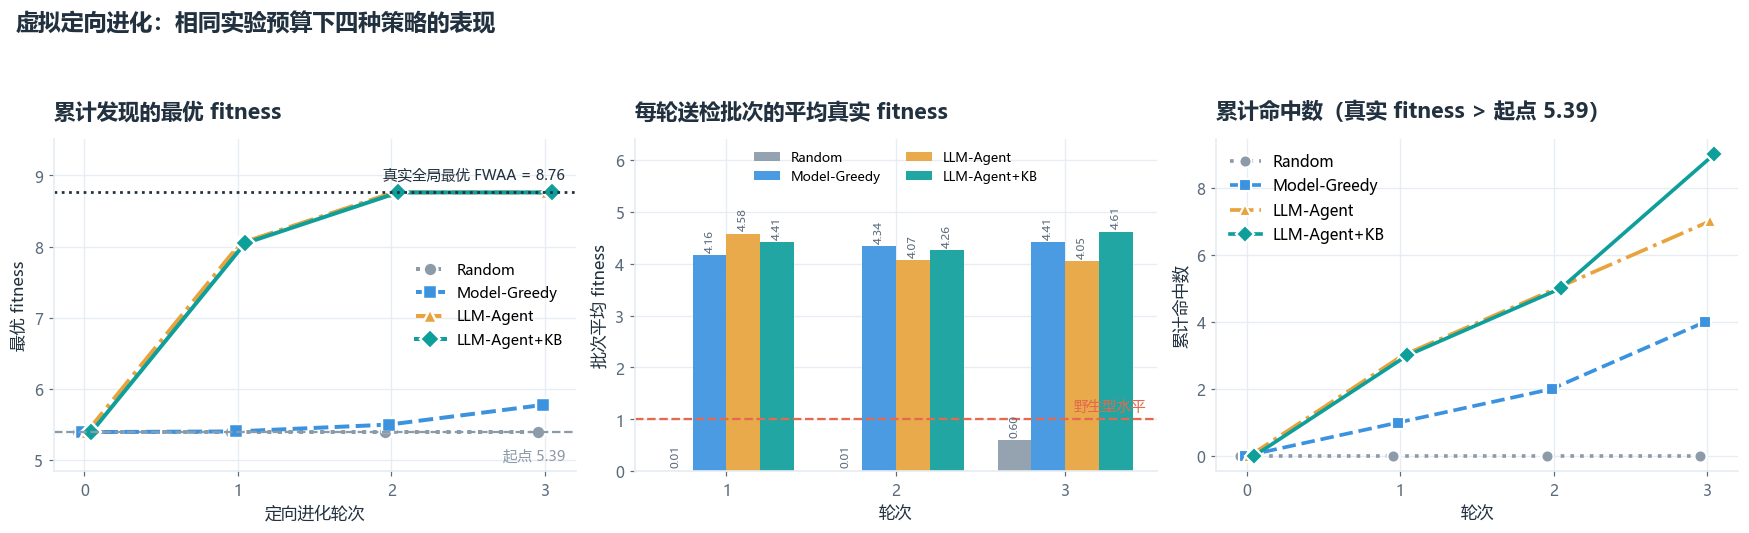

In [24]:
# 图 9：四种策略的 fitness 提升曲线
fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))

# 四条曲线可能完全重合（例如两个 Agent 同轮找到同一个最优变体），
# 因此用不同线型 + 轻微横向偏移，保证每条线都看得见
STYLES = {"Random": (":", "o"), "Model-Greedy": ("--", "s"),
          AGENT_NAME: ("-.", "^"), KB_NAME: ("-", "D")}
OFFSET = {"Random": -0.045, "Model-Greedy": -0.015, AGENT_NAME: 0.015, KB_NAME: 0.045}

ax = axes[0]
for res in results:
    d = res.to_frame()
    ls, mk = STYLES[res.strategy]
    ax.plot(d["round"] + OFFSET[res.strategy], d.best_fitness, marker=mk, markersize=9,
            linewidth=2.6, linestyle=ls, color=STRATEGY_COLORS[res.strategy],
            label=res.strategy, markeredgecolor="white", markeredgewidth=1.6)
ax.axhline(GLOBAL_BEST.fitness, color=PALETTE["ink"], linestyle=":", linewidth=1.8)
ax.annotate(f"真实全局最优 {GLOBAL_BEST.variant} = {GLOBAL_BEST.fitness:.2f}",
            (0.98, GLOBAL_BEST.fitness), xycoords=("axes fraction", "data"), ha="right",
            textcoords="offset points", xytext=(0, 9), fontsize=9.5, color=PALETTE["ink"])
ax.axhline(known.fitness.max(), color=PALETTE["muted"], linestyle="--", linewidth=1.5)
ax.annotate(f"起点 {known.fitness.max():.2f}", (0.98, known.fitness.max()),
            xycoords=("axes fraction", "data"), ha="right", textcoords="offset points",
            xytext=(0, -18), fontsize=9.5, color=PALETTE["muted"])
ax.set_xticks(range(N_ROUNDS + 1))
ax.set_ylim(known.fitness.max() - 0.55, GLOBAL_BEST.fitness + 0.75)
polish(ax, "累计发现的最优 fitness", "定向进化轮次", "最优 fitness")
ax.legend(loc="center right", fontsize=9.5)

ax = axes[1]
w = 0.2
for i, res in enumerate(results):
    d = res.to_frame()
    d = d[d["round"] > 0]
    bars = ax.bar(d["round"] + (i - 1.5) * w, d.batch_mean_fitness, width=w,
                  color=STRATEGY_COLORS[res.strategy], label=res.strategy, alpha=0.92)
    for b, v in zip(bars, d.batch_mean_fitness):
        ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v),
                    textcoords="offset points", xytext=(0, 4), ha="center",
                    fontsize=7.5, color=PALETTE["slate"], rotation=90)
ax.axhline(1.0, color=PALETTE["coral"], linestyle="--", linewidth=1.5)
ax.annotate("野生型水平", (0.98, 1.0), xycoords=("axes fraction", "data"), ha="right",
            textcoords="offset points", xytext=(0, 6), fontsize=9.5, color=PALETTE["coral"])
ax.set_xticks(range(1, N_ROUNDS + 1))
ax.set_ylim(0, 6.4)
polish(ax, "每轮送检批次的平均真实 fitness", "轮次", "批次平均 fitness")
ax.legend(loc="upper center", ncol=2, fontsize=8.5)

ax = axes[2]
for res in results:
    d = res.to_frame()
    ls, mk = STYLES[res.strategy]
    ax.plot(d["round"] + OFFSET[res.strategy], d.cum_hits, marker=mk, markersize=8,
            linewidth=2.4, linestyle=ls, color=STRATEGY_COLORS[res.strategy],
            label=res.strategy, markeredgecolor="white", markeredgewidth=1.4)
ax.set_xticks(range(N_ROUNDS + 1))
polish(ax, f"累计命中数（真实 fitness > 起点 {known.fitness.max():.2f}）", "轮次", "累计命中数")
ax.legend(loc="upper left")

fig.suptitle("虚拟定向进化：相同实验预算下四种策略的表现", x=0.012, ha="left",
             fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, "09_campaign_curves")
plt.show()

[图片已保存] runs/api/img/10_batch_quality.png


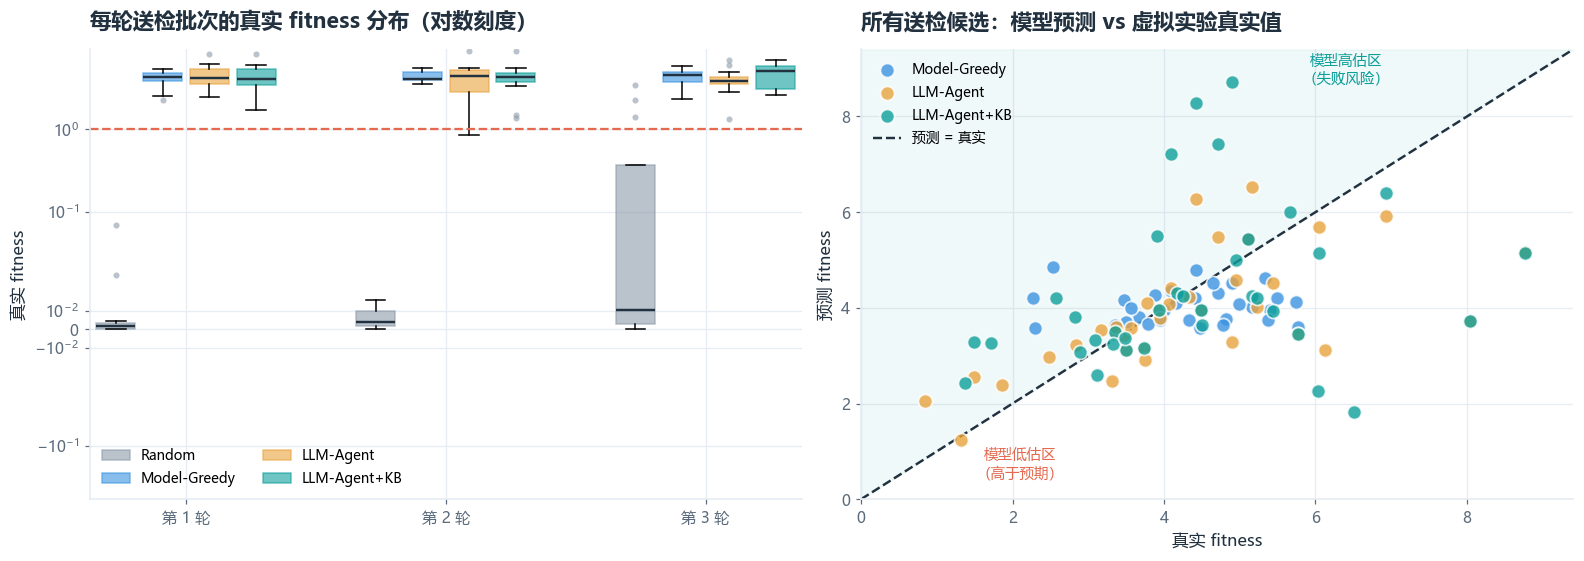

In [25]:
# 图 10：每轮批次的质量分布 + 预测误差
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

ax = axes[0]
positions, labels, colors_ = [], [], []
data = []
for ri in range(1, N_ROUNDS + 1):
    for si, res in enumerate(results):
        p = [pp for pp in res.proposals if pp.round_id == ri][0]
        data.append(p.batch.true_fitness.dropna().values)
        positions.append(ri * 5 + si * 0.9)
        colors_.append(STRATEGY_COLORS[res.strategy])
bp = ax.boxplot(data, positions=positions, widths=0.75, patch_artist=True, showfliers=True,
                medianprops=dict(color=PALETTE["ink"], linewidth=1.6),
                flierprops=dict(marker="o", markersize=4, markerfacecolor=PALETTE["muted"],
                                markeredgecolor="none", alpha=0.6))
for patch, c in zip(bp["boxes"], colors_):
    patch.set_facecolor(c); patch.set_alpha(0.6); patch.set_edgecolor(c)
ax.set_xticks([ri * 5 + 1.35 for ri in range(1, N_ROUNDS + 1)])
ax.set_xticklabels([f"第 {ri} 轮" for ri in range(1, N_ROUNDS + 1)])
ax.set_yscale("symlog", linthresh=0.05)
ax.axhline(1.0, color=PALETTE["coral"], linestyle="--", linewidth=1.5)
polish(ax, "每轮送检批次的真实 fitness 分布（对数刻度）", None, "真实 fitness")
ax.legend(handles=[mpatches.Patch(color=STRATEGY_COLORS[r.strategy], alpha=0.6, label=r.strategy)
                   for r in results], loc="lower left", ncol=2, fontsize=9)

ax = axes[1]
for res in results:
    if res.strategy == "Random":
        continue
    allb = pd.concat([p.batch for p in res.proposals], ignore_index=True)
    allb = allb.dropna(subset=["true_fitness"])
    ax.scatter(allb.true_fitness, allb.pred_fitness, s=85, alpha=0.8,
               color=STRATEGY_COLORS[res.strategy], edgecolor="white", linewidth=1.2,
               label=res.strategy, zorder=3)
lim = [0, 9.4]
ax.plot(lim, lim, color=PALETTE["ink"], linestyle="--", linewidth=1.6, label="预测 = 真实")
ax.fill_between(lim, lim, [9.4, 9.4], color=PALETTE["teal"], alpha=0.06)
ax.text(6.4, 8.7, "模型高估区\n（失败风险）", fontsize=9.5, color=PALETTE["teal"], ha="center")
ax.text(2.1, 0.45, "模型低估区\n（高于预期）", fontsize=9.5, color=PALETTE["coral"], ha="center")
ax.set_xlim(lim); ax.set_ylim(lim)
polish(ax, "所有送检候选：模型预测 vs 虚拟实验真实值", "真实 fitness", "预测 fitness")
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
save_fig(fig, "10_batch_quality")
plt.show()

In [26]:
# 14b. 每一轮的 Top-K 推荐（四种策略横向对比，用于回答"推荐是否越来越准")
for res in results:
    print("\n" + "-" * 100)
    print(f"策略 {res.strategy}")
    for p in res.proposals:
        tk = p.batch[p.batch.is_topk].sort_values("topk_rank")
        print(f"\n  第 {p.round_id} 轮   起点 {p.best_variant_before} "
              f"({p.best_fitness_before:.3f})   候选池 {p.n_candidates} 条")
        for _, r in tk.iterrows():
            line = (f"    #{int(r.topk_rank)}  {r.variant:<6} {r.mut_label:<32} "
                    f"预测 {r.pred_fitness:6.3f}   真实 {r.true_fitness:6.3f}")
            if "verdict" in tk.columns and isinstance(r.get("verdict"), str):
                line += f"   审查 {r['verdict']}"
            print(line)
            reason = r.get("recommendation_reason") if "recommendation_reason" in tk.columns else None
            if isinstance(reason, str) and reason:
                print(f"         理由: {reason}")
        best = tk.true_fitness.max()
        print(f"    -> 本轮 Top-{TOP_K} 最高真实 fitness = {best:.3f}"
              f"（相对起点 {best - p.best_fitness_before:+.3f}）")

print("\n" + "-" * 100)
print("[解读] 对比各策略每轮 Top-K 的真实 fitness，可以看出推荐质量是否随轮次改善；")
print("       应分别检查高估与低估案例，不能仅凭个别候选判断模型的整体偏差。")



----------------------------------------------------------------------------------------------------
策略 Random

  第 1 轮   起点 VWGF (5.391)   候选池 147193 条
    #1  FISS   V39F + D40I + G41S + V54S        预测  0.301   真实  0.070
    #2  KYTG   V39K + D40Y + G41T + V54G        预测  0.148   真实  0.004
    #3  KVND   V39K + D40V + G41N + V54D        预测  0.067   真实  0.000
    #4  MQMM   V39M + D40Q + G41M + V54M        预测  0.022   真实  0.029
    #5  YMQM   V39Y + D40M + G41Q + V54M        预测  0.017   真实  0.000
    -> 本轮 Top-5 最高真实 fitness = 0.070（相对起点 -5.321）

  第 2 轮   起点 VWGF (5.391)   候选池 147181 条
    #1  LCNC   V39L + D40C + G41N + V54C        预测  0.097   真实  0.015
    #2  WNYN   V39W + D40N + G41Y + V54N        预测  0.060   真实  0.008
    #3  FVTC   V39F + D40V + G41T + V54C        预测  0.045   真实  0.014
    #4  VTYC   D40T + G41Y + V54C               预测  0.040   真实  0.016
    #5  NASN   V39N + D40A + G41S + V54N        预测  0.037   真实  0.004
    -> 本轮 Top-5 最高真实 fitness = 0.016（相对起点 -5.375）

  第

In [27]:
# 15. 离线规则引擎与基线的多种子重复实验
SEEDS = [11, 22, 33, 44, 55, 66, 77, 88]
factories = {
    "Random": lambda s: RandomStrategy(seed=s),
    "Model-Greedy": lambda s: ModelGreedyStrategy(seed=s),
    "Rule-Agent": lambda s: DirectedEvolutionAgent(
        llm_repl, AgentConfig(name="Rule-Agent", use_knowledge=False, seed=s)),
    "Rule-Agent+KB": lambda s: DirectedEvolutionAgent(
        llm_repl, AgentConfig(name="Rule-Agent+KB", use_knowledge=True, seed=s), DesignRuleBook(), kg),
}
rep_list = []
for name, factory in factories.items():
    print(f"\n>>> {name}: {len(SEEDS)} 个种子")
    rep_list.append(run_replicates(factory, known, oracle_full, allowed, holdout, SEEDS,
                                   n_rounds=N_ROUNDS, model_kind=BEST_KIND, verbose=True))
rep = pd.concat(rep_list, ignore_index=True)
agg = aggregate_replicates(rep, target_fitness=float(GLOBAL_BEST.fitness), verbose=True)
print("\n[解释] Rule-Agent 的重复结果衡量离线搜索机制，不代表真实 LLM 的成功率或稳定性。")



>>> Random: 8 个种子


    seed=11   最终最优  5.391 (VWGF)  累计命中  0  模型 Spearman 0.5175


    seed=22   最终最优  5.391 (VWGF)  累计命中  0  模型 Spearman 0.4839


    seed=33   最终最优  5.391 (VWGF)  累计命中  0  模型 Spearman 0.4928


    seed=44   最终最优  5.391 (VWGF)  累计命中  0  模型 Spearman 0.4910


...

    seed=44   最终最优  8.762 (FWAA)  累计命中  7  模型 Spearman 0.4687


    seed=55   最终最优  8.762 (FWAA)  累计命中  7  模型 Spearman 0.4645


    seed=66   最终最优  8.762 (FWAA)  累计命中 10  模型 Spearman 0.4778


    seed=77   最终最优  8.762 (FWAA)  累计命中 11  模型 Spearman 0.4682


    seed=88   最终最优  8.762 (FWAA)  累计命中  7  模型 Spearman 0.4706

多种子重复实验汇总（8 个随机种子 × 每轮 12 次虚拟实验，均值 ± 标准差）
  策略                         最终最优         累计命中       批次均值       超野生型     批次低功能      触及位点41       成功率      成功时实验数
  Rule-Agent+KB    8.762 ± 0.000    7.5 ±  2.0      4.266      97.6%      0.00        7.96      100%        28.5
  Rule-Agent       8.672 ± 0.253    9.0 ±  1.8      4.401      98.3%      0.08        6.71       88%        18.9
  Model-Greedy     6.927 ± 1.522    5.8 ±  2.7      4.366     100.0%      0.00        7.79       38%        36.0
  Random           5.391 ± 0.000    0.0 ±  0.0      0.094       3.5%     11.08       11.50        0%         nan

  注：成功率 = 在 3 轮 × 12 次实验的预算内找到真实全局最优(fitness=8.762) 的重复实验比例；实验数只对成功重复求平均，按首次达到目标的整批实验计数；全部未找到时记为缺失，需结合成功率解读。

[解释] Rule-Agent 的重复结果衡量离线搜索机制，不代表真实 LLM 的成功率或稳定性。


[图片已保存] runs/api/img/11_replicate_summary.png


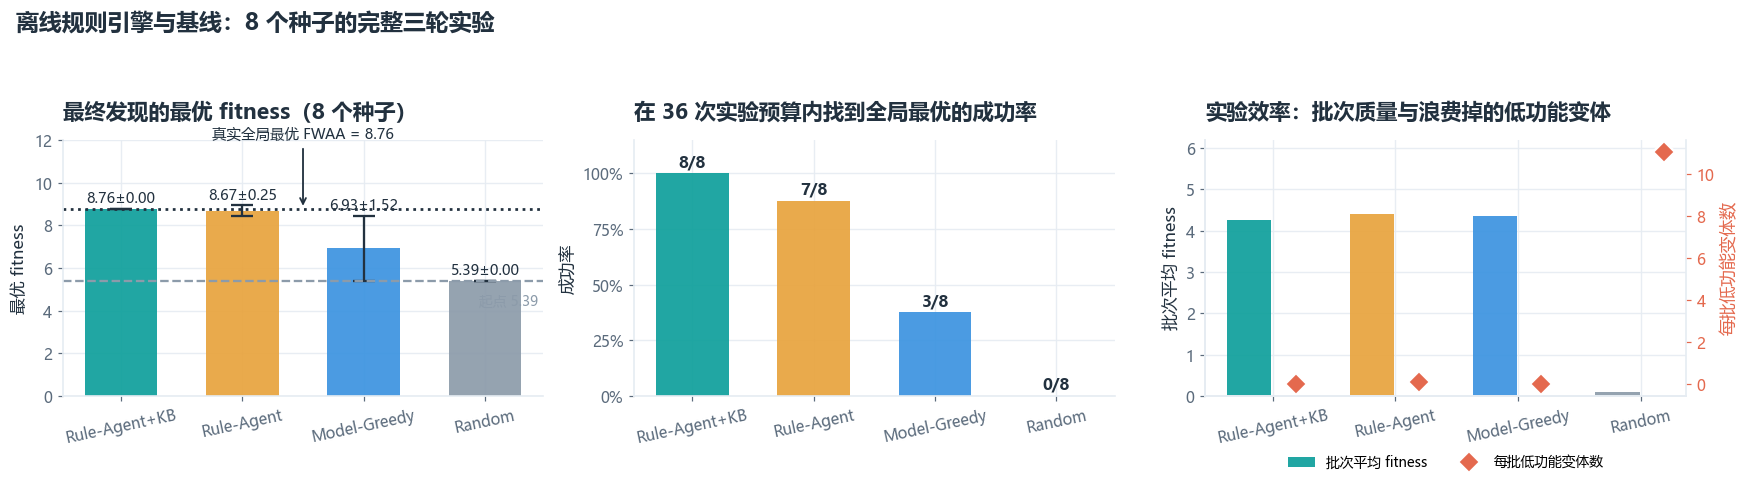

In [28]:
# 图 11：多种子重复实验汇总（带误差棒）
fig, axes = plt.subplots(1, 3, figsize=(16, 5.0))
order = agg.strategy.tolist()
cols = [STRATEGY_COLORS[s] for s in order]
xx = np.arange(len(order))

ax = axes[0]
ax.bar(xx, agg.final_best_mean, yerr=agg.final_best_std, width=0.6, color=cols, alpha=0.92,
       capsize=7, error_kw=dict(ecolor=PALETTE["ink"], lw=1.5, capthick=1.5))
ax.axhline(GLOBAL_BEST.fitness, color=PALETTE["ink"], linestyle=":", linewidth=1.8)
ax.axhline(known.fitness.max(), color=PALETTE["muted"], linestyle="--", linewidth=1.5)
ax.annotate(f"起点 {known.fitness.max():.2f}", (0.99, known.fitness.max()),
            xycoords=("axes fraction", "data"), ha="right", textcoords="offset points",
            xytext=(0, -16), fontsize=9, color=PALETTE["muted"])
for i, r in agg.iterrows():
    ax.text(i, r.final_best_mean + r.final_best_std + 0.3,
            f"{r.final_best_mean:.2f}±{r.final_best_std:.2f}",
            ha="center", fontsize=9.5, color=PALETTE["ink"])
ax.set_xticks(xx); ax.set_xticklabels(order, rotation=12)
ax.set_ylim(0, 12.0)
ax.annotate(f"真实全局最优 {GLOBAL_BEST.variant} = {GLOBAL_BEST.fitness:.2f}",
            (0.5, GLOBAL_BEST.fitness), xycoords=("axes fraction", "data"), ha="center",
            textcoords="offset points", xytext=(0, 46), fontsize=9.5, color=PALETTE["ink"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["ink"], linewidth=1.2))
polish(ax, f"最终发现的最优 fitness（{len(SEEDS)} 个种子）", None, "最优 fitness")

ax = axes[1]
ax.bar(xx, agg.success_rate, width=0.6, color=cols, alpha=0.92)
for i, r in agg.iterrows():
    ax.text(i, r.success_rate + 0.03, f"{int(r.n_success)}/{len(SEEDS)}",
            ha="center", fontsize=10.5, color=PALETTE["ink"], fontweight="bold")
ax.set_xticks(xx); ax.set_xticklabels(order, rotation=12)
ax.set_ylim(0, 1.15)
ax.set_yticks([0, .25, .5, .75, 1.0]); ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
polish(ax, f"在 {BATCH_SIZE * N_ROUNDS} 次实验预算内找到全局最优的成功率", None, "成功率")

ax = axes[2]
ax.bar(xx - 0.19, agg.batch_mean_fitness, width=0.36, color=cols, alpha=0.92,
       label="批次平均 fitness")
ax2 = ax.twinx()
ax2.plot(xx + 0.19, agg.n_dead_per_batch, marker="D", markersize=10, linewidth=0,
         color=PALETTE["coral"], markeredgecolor="white", markeredgewidth=1.6,
         label="每批低功能变体数")
ax2.set_ylabel("每批低功能变体数", color=PALETTE["coral"])
ax2.tick_params(axis="y", colors=PALETTE["coral"])
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax.set_xticks(xx); ax.set_xticklabels(order, rotation=12)
ax.set_ylim(0, 6.2)
polish(ax, "实验效率：批次质量与浪费掉的低功能变体", None, "批次平均 fitness")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower center", bbox_to_anchor=(0.5, -0.34),
          ncol=2, fontsize=9)

fig.suptitle(f"离线规则引擎与基线：{len(SEEDS)} 个种子的完整三轮实验",
             x=0.012, ha="left", fontsize=15, fontweight="bold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, "11_replicate_summary")
plt.show()


[位点分布] 主实验每批候选相对 WT 的替换比例
              touch_pos39  touch_pos40  touch_pos41  touch_pos54
strategy                                                        
LLM-Agent            91.7         94.4         52.8        100.0
LLM-Agent+KB         88.9         83.3         72.2        100.0
Model-Greedy         77.8         88.9         69.4        100.0
Random               91.7         94.4         97.2         94.4
位点分布描述搜索行为；单凭改动位点 41 的频率，不能判断是否进行了有效的上位效应推理。

[生成来源]
    strategy               source  n  mean_true  max_true
   LLM-Agent hypothesis_expansion  6      4.779     6.928
   LLM-Agent             llm_seed  8      5.039     8.762
   LLM-Agent   random_exploration  3      2.635     3.748
   LLM-Agent            recombine 14      4.423     8.045
   LLM-Agent  residue_enumeration  5      2.699     3.951
LLM-Agent+KB  epistasis_extension  6      2.926     4.172
LLM-Agent+KB             llm_seed  8      5.726     8.762
LLM-Agent+KB   random_exploration  3      5.087     6.509
LLM-Agent

[图片已保存] runs/api/img/12_position_focus.png


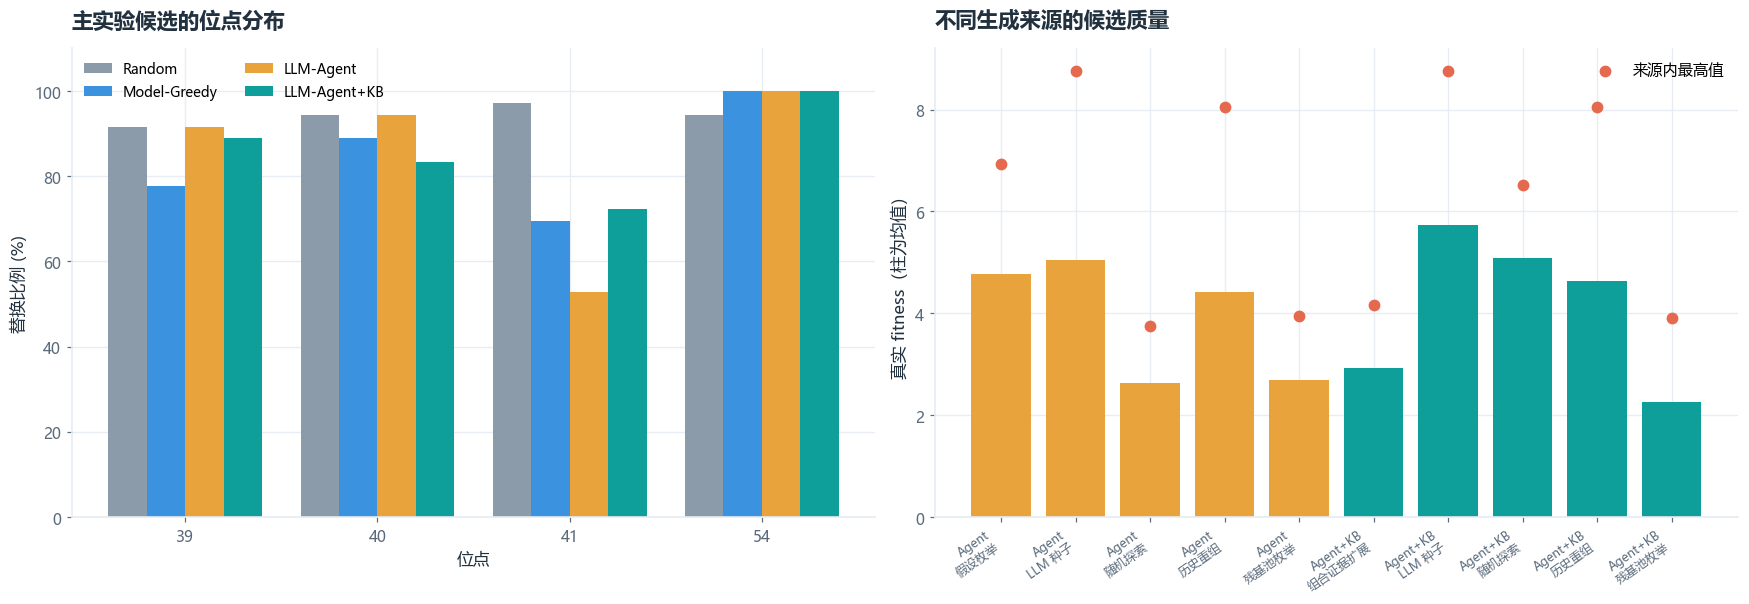

In [29]:
# 16. 主实验中的位点分布与候选来源
source_names = {"llm_seed": "LLM 种子", "hypothesis_expansion": "假设枚举", "recombine": "历史重组",
                "epistasis_extension": "组合证据扩展", "residue_enumeration": "残基池枚举",
                "random_exploration": "随机探索"}
touch_cols = [f"touch_pos{p}" for p in MUT_POSITIONS]
touch = rounds_df[rounds_df["round"] > 0].groupby("strategy")[touch_cols].mean() / BATCH_SIZE
print("[位点分布] 主实验每批候选相对 WT 的替换比例")
print((touch * 100).round(1).to_string())
print("位点分布描述搜索行为；单凭改动位点 41 的频率，不能判断是否进行了有效的上位效应推理。")
rows, links = [], []
for res in results:
    if res.strategy not in (AGENT_NAME, KB_NAME):
        continue
    allb = pd.concat([p.batch.assign(round=p.round_id) for p in res.proposals], ignore_index=True)
    for source, group in allb.groupby("source_type"):
        rows.append({"strategy": res.strategy, "source": source, "n": len(group),
                     "mean_true": group.true_fitness.mean(), "max_true": group.true_fitness.max()})
    for (round_id, hid), group in allb.dropna(subset=["hypothesis_id"]).groupby(["round", "hypothesis_id"]):
        links.append({"strategy": res.strategy, "round": round_id, "hypothesis_id": hid,
                      "n": len(group), "mean_true": group.true_fitness.mean()})
source_summary = pd.DataFrame(rows)
print("\n[生成来源]", source_summary.round(3).to_string(index=False), sep="\n")
print("\n[直接关联假设]", pd.DataFrame(links).round(3).to_string(index=False), sep="\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))
for i, res in enumerate(results):
    axes[0].bar(np.arange(4) + (i - 1.5) * 0.2, touch.loc[res.strategy].values * 100,
                width=0.2, color=STRATEGY_COLORS[res.strategy], label=res.strategy)
axes[0].set_xticks(range(4), [str(p) for p in MUT_POSITIONS])
axes[0].set_ylim(0, 110)
polish(axes[0], "主实验候选的位点分布", "位点", "替换比例 (%)")
axes[0].legend(fontsize=9, ncol=2)
x = np.arange(len(source_summary))
axes[1].bar(x, source_summary.mean_true, color=[STRATEGY_COLORS[s] for s in source_summary.strategy])
axes[1].scatter(x, source_summary.max_true, color=PALETTE["coral"], s=45, label="来源内最高值")
labels = [f"{r.strategy.replace(AGENT_NAME, 'Agent')}\n{source_names.get(r.source, r.source)}"
          for _, r in source_summary.iterrows()]
axes[1].set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
polish(axes[1], "不同生成来源的候选质量", None, "真实 fitness（柱为均值）")
axes[1].legend()
fig.tight_layout()
save_fig(fig, "12_position_focus")
plt.show()


In [30]:
# 17. 成功案例、失败案例与模型误差
kb_res = next(r for r in results if r.strategy == KB_NAME)
plain_res = next(r for r in results if r.strategy == AGENT_NAME)
kb_all = pd.concat([p.batch.assign(round=p.round_id) for p in kb_res.proposals], ignore_index=True)
kb_all["误差"] = kb_all.pred_fitness - kb_all.true_fitness
for title, subset in [("成功案例", kb_all.nlargest(5, "true_fitness")),
                      ("高估案例", kb_all[kb_all["误差"] > 0].nlargest(5, "误差")),
                      ("低估案例", kb_all[kb_all["误差"] < 0].nsmallest(3, "误差"))]:
    print(f"\n【{title}】")
    if subset.empty:
        print("本次送检批次中没有符合该条件的候选。")
    for _, r in subset.iterrows():
        print(f"  R{int(r['round'])} {r.variant}: 预测 {r.pred_fitness:.3f}，真实 {r.true_fitness:.3f}，误差 {r['误差']:+.3f}")
        print(f"  来源 {r.source_type}；关联假设 {r.hypothesis_id or '无直接关联'}；审查 {r.verdict}")
        print(f"  依据: {r.recommendation_reason}")
        print(f"  风险: {r.risk}")
print("\n[解释] 高阶组合的分布外预测、测量噪声与位点相互作用都可能贡献误差；仅凭预测误差不能确认具体结构机制。")
for res in results:
    allb = pd.concat([p.batch for p in res.proposals], ignore_index=True)
    error = allb.pred_fitness - allb.true_fitness
    print(f"{res.strategy}: MAE={error.abs().mean():.3f}，平均偏差={error.mean():+.3f}，高估比例={(error > 0).mean():.1%}")



【成功案例】
  R2 FWAA: 预测 5.144，真实 8.762，误差 -3.618
  来源 llm_seed；关联假设 H1；审查 accept_with_caution
  依据: V39F与亲本相同；D40W单点有提升记录，但体积剧增属高风险探索。
  风险: 表面位W侧链过大，易堆积错配。
  R1 FYAA: 预测 3.720，真实 8.045，误差 -4.325
  来源 recombine；关联假设 无直接关联；审查 accept_with_caution
  依据: D40Y有益，但V39F与G41A均历史降低，四突变叠加风险高。
  风险: 两个降低突变叠加。
  R3 FFAA: 预测 6.407，真实 6.928，误差 -0.521
  来源 llm_seed；关联假设 H4；审查 accept_with_caution
  依据: D40F历史提升且预测较高，但V39F历史降低，双芳香替换需验证堆积。
  风险: 双大体积芳香可能破坏局部堆积。
  R3 FWAG: 预测 1.823，真实 6.509，误差 -4.687
  来源 random_exploration；关联假设 无直接关联；审查 accept_with_caution
  依据: 仅V54A→G，预测低但不确定高；不可仅因低预测否决探索。
  风险: V54G可能破坏疏水核心。
  R3 IWAA: 预测 5.137，真实 6.042，误差 -0.905
  来源 llm_seed；关联假设 H1；审查 accept
  依据: 仅V39F→I，V39I与D40W历史均提升，预测中上且低不确定。
  风险: I39侧链较大，可能影响环区。

【高估案例】
  R2 IYAA: 预测 8.290，真实 4.426，误差 +3.864
  来源 llm_seed；关联假设 H4；审查 accept
  依据: V39I保守提升，D40Y为亲本已验证位点，组合机制自洽、风险低。
  风险: 不确定度±0.42，需实测确认叠加。
  R2 LYAA: 预测 8.712，真实 4.894，误差 +3.819
  来源 llm_seed；关联假设 H4；审查 accept
  依据: V39L为保守疏水替换且单点历史提升，其余位点与亲本一致，处方最稳妥。
  风险: 埋藏位侧链

In [31]:
# 18. Agent 的作用与证据边界
for res in results:
    final = res.rounds[-1]
    print(f"{res.strategy}: 最终最优 {final['best_variant']}={final['best_fitness']:.3f}，送检 {sum(r['n_new'] for r in res.rounds)} 条")
print("\n1. Agent 将实测数据转化为假设，并通过候选生成、模型评估和审稿形成反馈闭环。")
print("2. 与 Model-Greedy 的差异同时包含候选生成、探索、多样性和审稿，不能把总增益单独归因于 LLM。")
print(f"3. 本次主实验后端为 {llm.backend}，每种策略只有一次 campaign；离线 8 种子结果属于 Rule-Agent，不能代替 LLM 重复实验。")
print("4. 初始模型的静态排名不能换算为迭代搜索需要的实验次数；各策略会随新数据重新训练。")
print("5. 累计最优不下降是定义带来的性质，应同时检查批次均值、命中率及失败候选。")
print("6. GB1 是公开且常用的基准，LLM 的预训练知识也可能影响设计；本项目没有排除这种影响。")
print("7. 该实验模拟四位点文库的离线搜索，不证明对其他蛋白或真实湿实验具有相同效果。")


Random: 最终最优 VWGF=5.391，送检 36 条
Model-Greedy: 最终最优 IWGF=5.772，送检 36 条
LLM-Agent: 最终最优 FWAA=8.762，送检 36 条
LLM-Agent+KB: 最终最优 FWAA=8.762，送检 36 条

1. Agent 将实测数据转化为假设，并通过候选生成、模型评估和审稿形成反馈闭环。
2. 与 Model-Greedy 的差异同时包含候选生成、探索、多样性和审稿，不能把总增益单独归因于 LLM。
3. 本次主实验后端为 api，每种策略只有一次 campaign；离线 8 种子结果属于 Rule-Agent，不能代替 LLM 重复实验。
4. 初始模型的静态排名不能换算为迭代搜索需要的实验次数；各策略会随新数据重新训练。
5. 累计最优不下降是定义带来的性质，应同时检查批次均值、命中率及失败候选。
6. GB1 是公开且常用的基准，LLM 的预训练知识也可能影响设计；本项目没有排除这种影响。
7. 该实验模拟四位点文库的离线搜索，不证明对其他蛋白或真实湿实验具有相同效果。


    seed=11   最终最优  8.762 (FWAA)  累计命中  9  模型 Spearman 0.4707


    seed=22   最终最优  8.762 (FWAA)  累计命中  8  模型 Spearman 0.4733


    seed=33   最终最优  8.762 (FWAA)  累计命中  5  模型 Spearman 0.4771


    seed=44   最终最优  8.762 (FWAA)  累计命中  8  模型 Spearman 0.4694


    seed=55   最终最优  8.762 (FWAA)  累计命中 10  模型 Spearman 0.4773


    seed=66   最终最优  8.762 (FWAA)  累计命中  9  模型 Spearman 0.4747


    seed=77   最终最优  8.762 (FWAA)  累计命中  9  模型 Spearman 0.4708


    seed=88   最终最优  8.762 (FWAA)  累计命中  7  模型 Spearman 0.4821

多种子重复实验汇总（8 个随机种子 × 每轮 12 次虚拟实验，均值 ± 标准差）
  策略                         最终最优         累计命中       批次均值       超野生型     批次低功能      触及位点41       成功率      成功时实验数
  Rule-Agent+KB-static   8.762 ± 0.000    8.1 ±  1.6      4.275      96.9%      0.08        6.25      100%        18.0
  Rule-Agent+KB    8.762 ± 0.000    7.5 ±  2.0      4.266      97.6%      0.00        7.96      100%        28.5

  注：成功率 = 在 3 轮 × 12 次实验的预算内找到真实全局最优(fitness=8.762) 的重复实验比例；实验数只对成功重复求平均，按首次达到目标的整批实验计数；全部未找到时记为缺失，需结合成功率解读。

[配对结果] 允许补偿证据相对关闭证据：
胜 0，平 8，负 0
两组使用相同种子、初始数据、候选生成方法、模型和 36 次实验预算；仅切换规则中的补偿证据。
该消融衡量规则引擎中的这一机制，不代表真实 LLM 消融，也不预设证据机制一定改善结果。
[图片已保存] runs/api/img/13_rescue_ablation.png


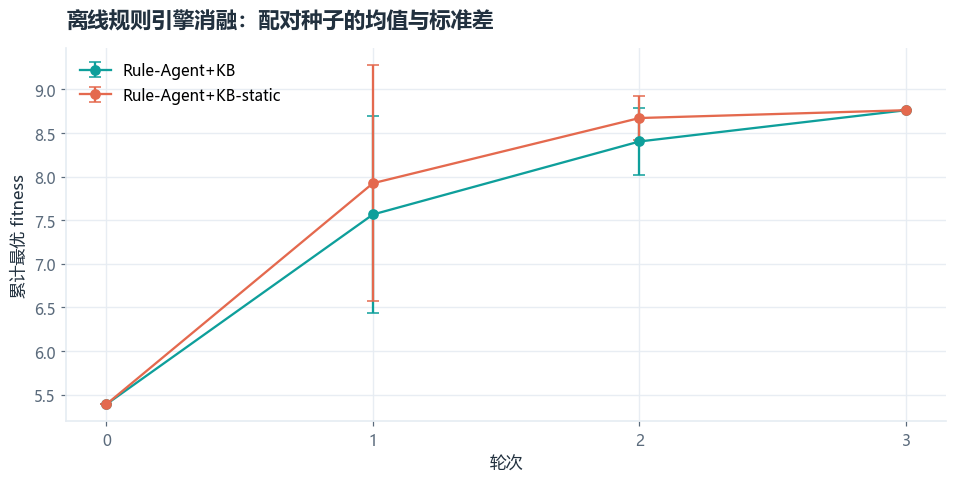

In [32]:
# 19. 配对消融：双突变补偿证据对规则引擎搜索的影响
static_factory = lambda s: DirectedEvolutionAgent(
    LLMClient(backend="offline"),
    AgentConfig(name="Rule-Agent+KB-static", use_knowledge=True, seed=s),
    DesignRuleBook(use_rescue_evidence=False), kg)
static_rep = run_replicates(static_factory, known, oracle_full, allowed, holdout, SEEDS,
                            n_rounds=N_ROUNDS, model_kind=BEST_KIND, verbose=True)
ablation = pd.concat([rep[rep.strategy == "Rule-Agent+KB"], static_rep], ignore_index=True)
ablation_summary = aggregate_replicates(ablation, target_fitness=float(GLOBAL_BEST.fitness), verbose=True)
paired = ablation[ablation["round"] == N_ROUNDS].pivot(index="seed", columns="strategy", values="best_fitness")
difference = paired["Rule-Agent+KB"] - paired["Rule-Agent+KB-static"]
print("\n[配对结果] 允许补偿证据相对关闭证据：")
print(f"胜 {int((difference > 1e-9).sum())}，平 {int((difference.abs() <= 1e-9).sum())}，负 {int((difference < -1e-9).sum())}")
print("两组使用相同种子、初始数据、候选生成方法、模型和 36 次实验预算；仅切换规则中的补偿证据。")
print("该消融衡量规则引擎中的这一机制，不代表真实 LLM 消融，也不预设证据机制一定改善结果。")
fig, ax = plt.subplots(figsize=(8.8, 4.5))
for name, group in ablation.groupby("strategy"):
    grouped = group.groupby("round").best_fitness.agg(["mean", "std"])
    ax.errorbar(grouped.index, grouped["mean"], yerr=grouped["std"], marker="o", capsize=4,
                color=STRATEGY_COLORS[name], label=name)
polish(ax, "离线规则引擎消融：配对种子的均值与标准差", "轮次", "累计最优 fitness")
ax.set_xticks(range(N_ROUNDS + 1)); ax.legend()
fig.tight_layout(); save_fig(fig, "13_rescue_ablation"); plt.show()


In [33]:
# 20. 导出全部实验结果
save_campaign_artifacts(results, summary)

cmp_df.to_csv(RESULT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
rounds_df.to_csv(RESULT_DIR / "campaign_rounds.csv", index=False, encoding="utf-8-sig")
rep.to_csv(RESULT_DIR / "replicates.csv", index=False, encoding="utf-8-sig")
agg.to_csv(RESULT_DIR / "replicate_summary.csv", index=False, encoding="utf-8-sig")
summary.to_csv(RESULT_DIR / "campaign_summary.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(pair_preference(epi_known, top=60)).to_csv(
    RESULT_DIR / "epistasis_top.csv", index=False, encoding="utf-8-sig")
position_sensitivity(known).to_csv(RESULT_DIR / "position_profile.csv",
                                   index=False, encoding="utf-8-sig")
aa_df.reset_index().to_csv(RESULT_DIR / "aa_properties.csv", index=False, encoding="utf-8-sig")
df.nlargest(50, "fitness")[["variant", "mut_label", "n_mut", "fitness"]].to_csv(
    RESULT_DIR / "global_top50.csv", index=False, encoding="utf-8-sig")
llm.dump_transcript()
ablation.to_csv(RESULT_DIR / "ablation_rounds.csv", index=False, encoding="utf-8-sig")
ablation_summary.to_csv(RESULT_DIR / "ablation_summary.csv", index=False, encoding="utf-8-sig")
source_summary.to_csv(RESULT_DIR / "source_summary.csv", index=False, encoding="utf-8-sig")

overview = {
    "dataset": DATASET_NAME, "protein": PROTEIN_NAME, "task": TASK_DESC,
    "wt_sequence": wt_seq, "wt_combo": WT_COMBO, "positions": MUT_POSITIONS,
    "n_variants": int(len(df)), "space_size": 20 ** len(MUT_POSITIONS),
    "coverage": float(len(df) / 20 ** len(MUT_POSITIONS)),
    "n_dead": int((df.fitness == 0).sum()),
    "fitness_max": float(df.fitness.max()), "fitness_median": float(df.fitness.median()),
    "global_best": {"variant": str(GLOBAL_BEST.variant), "label": str(GLOBAL_BEST.mut_label),
                    "fitness": float(GLOBAL_BEST.fitness)},
    "splits": {k: int(len(v)) for k, v in splits.items() if k != "known"},
    "start_best": {"variant": str(known.loc[known.fitness.idxmax(), "variant"]),
                   "fitness": float(known.fitness.max())},
    "best_model": BEST_KIND,
    "model_metrics": {"val": {k: float(v) for k, v in m_val.items()},
                      "test": {k: float(v) for k, v in m_test.items()}},
    "structural_context": {str(k): v for k, v in STRUCTURAL_CONTEXT.items()},
    "n_rounds": N_ROUNDS, "batch_size": BATCH_SIZE, "top_k": TOP_K,
    "seeds": SEEDS,
    "llm_backend": llm.backend, "llm_description": llm.description,
    # 前端展示用：直接给出模型名，比 "api" 这个字样信息量大
    "llm_label": (llm.model if llm.backend == "api" else "离线确定性引擎"),
    "llm_usage": llm.usage_report(),
    "llm_backend_replicates": "offline",
    "replicate_agent_names": ["Rule-Agent", "Rule-Agent+KB"],
    "main_agent_names": [AGENT_NAME, KB_NAME],
    "llm_main_campaigns_per_strategy": 1 if llm.backend == "api" else 0,
    "wt_sequence_representation": "56 aa GB1 domain; FLIP 265 aa construct retained in data/raw",
    "structural_positions": {str(p): STRUCTURAL_CONTEXT[p] for p in MUT_POSITIONS},
    "images": sorted(p.name for p in IMG_DIR.glob("*.png")),
}
with open(RESULT_DIR / "overview.json", "w", encoding="utf-8") as f:
    json.dump(overview, f, ensure_ascii=False, indent=2)
print(f"[保存] 总览 -> {rel(RESULT_DIR / 'overview.json')}")

model.save("fitness_model")
print(f"\n[完成] 共生成 {len(list(IMG_DIR.glob('*.png')))} 张图片，"
      f"{len(list(RESULT_DIR.glob('*')))} 个结果文件。")
print(f"[完成] 启动 Console Demo:  python demo.py --backend offline")

# 记录数据、参数与软件版本，便于定位实验条件。
import hashlib
import importlib.metadata
from datetime import datetime, timezone
from src.config import RAW_CSV
raw_source = RAW_CSV.with_suffix(".csv.zip")
manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "main_backend": llm.backend, "allow_api_fallback": llm.allow_fallback,
    "llm_model": llm.model if llm.backend == "api" else None,
    "temperature": llm.temperature, "main_seed": 42, "replicate_seeds": SEEDS,
    "initial_assays": len(known), "rounds": N_ROUNDS, "batch_size": BATCH_SIZE,
    "model_kind": BEST_KIND, "target_transform": "log10(fitness + 0.01)",
    "python": sys.version.split()[0],
    "versions": {package: importlib.metadata.version(package) for package in
                 ["numpy", "pandas", "scipy", "scikit-learn", "xgboost", "matplotlib", "nbformat", "nbclient"]},
    "data_sha256": hashlib.sha256(raw_source.read_bytes()).hexdigest(),
    "source_sha256": {str(file.relative_to(ROOT)): hashlib.sha256(file.read_bytes()).hexdigest()
                      for file in sorted((ROOT / "src").glob("*.py"))},
}
(RESULT_DIR / "run_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")


[保存] campaign 结果 -> runs/api/results/campaigns.json
[保存] Agent 交互记录(33 次) -> runs/api/results/agent_transcript.json
[保存] 总览 -> runs/api/results/overview.json
[保存] 模型 -> runs/api/models/fitness_model.pkl

[完成] 共生成 13 张图片，16 个结果文件。
[完成] 启动 Console Demo:  python demo.py --backend offline


1786